In [1]:
'''
To run this shole jupyter notebook as a python script follow this:

(1) activate conda environemt
(2) go to where this notebook is located in your computer
(3) use `python` to enter python with in your shell/terminal
(4) follow the above syntax


from json import load

filename = 'downstream_analyses.ipynb'
with open(filename) as fp:
    nb = load(fp)

for cell in nb['cells']:
    if cell['cell_type'] == 'code':
        source = ''.join(line for line in cell['source'] if not line.startswith('%'))
        exec(source, globals(), locals())
'''

"\nTo run this shole jupyter notebook as a python script follow this:\n\n(1) activate conda environemt\n(2) go to where this notebook is located in your computer\n(3) use `python` to enter python with in your shell/terminal\n(4) follow the above syntax\n\n\nfrom json import load\n\nfilename = 'downstream_analyses.ipynb'\nwith open(filename) as fp:\n    nb = load(fp)\n\nfor cell in nb['cells']:\n    if cell['cell_type'] == 'code':\n        source = ''.join(line for line in cell['source'] if not line.startswith('%'))\n        exec(source, globals(), locals())\n"

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
from utils import *
import glob
import os
import math
from IPython.display import display
import seaborn as sns
# from scipy.stats import * #false_discovery_control


/Users/snaranjo/miniconda3/envs/dahan_optimus/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
## HELPER FUCNTIONS FOR LARET
def fdr_bhmethod(p_vals):
    '''
    BH==Benjamin-Hochberg method. Entails first ranking all p values from smallest (1t)
    to largets (last). So, ranking them. Then, adjusting each p-value accoring to rank.
    '''
    from scipy.stats import rankdata
    ps = np.asfarray(p_vals)
    ranked_p_values = rankdata(ps)
    print(ranked_p_values)
    fdr = ps * (len(ps) / ranked_p_values)
    fdr[fdr > 1] = 1
    return fdr

def bonferroni_adj(p_vals):
    ps = np.asfarray(p_vals)
    num_of_tests = len(ps)
    print(ps)
    adj_ps = ps * num_of_tests
    print(adj_ps) # should be same nums but times constant 4950 (from_parcellation)
    adj_ps[adj_ps > 1] = 1
    return adj_ps 

In [4]:
# for later data viz
from_parcellation = 100
from_atlas="schf" #schf, glasser
parcellation="schaefer"
hemi_cond="1L"
parcellation_corr_type="full"
matrix_type="connectome" #connectome or topography
topo_chosen="ICA" #ICA
topo_dim = 15 if topo_chosen == 'ICA' else 20
translation=f"{topo_chosen}d{topo_dim}_{from_atlas}d{from_parcellation}"  #"ICAd15_ICAd15" #f"ICAd15_{from_atlas}d{from_parcellation}" # needs to be "" type of string
print(f"Translation: {translation}")
# version = "normICAdemeanMAT" #normICAdemeanfishzMAT normICArawMAT. normICAdemeanMAT
version = "normICAdemeanMAT" if topo_chosen == 'ICA' else "normIMdemeanMAT"
local_flag=True
if local_flag:
    using_local_root="/Users/snaranjo/Desktop/neurotranslate/mount_point"
else:
    using_local_root=""
scratch_path=f"{using_local_root}/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch"
root=f"{scratch_path}/NeuroTranslate/surf2netmat"
model_output_names = ["SiTLN", "kvSiTLN", "kSiTBGT", "kvSiTBGT"]
datasets_list = ["ABCD", "HCPYA"]
# datasets = datasets_list[0]
datasets = "ABCD" if topo_chosen == "ICA" else "infomap_prior_ABCDdr"
chosen_one = 0  #corresponds to ["kSiTLN", "kvSiTLN", "kSiTBGT", "kvSiTBGT"]
dataset_choice = 1 # 0==HCPYA, 1==ABCD, 2==HCPYA_ABCDdr
ica_reconstuction=0
if translation == "ICAd15_ICAd15":
    version = "normICAnormICA" #over ride what it was prior
    ica_reconstuction=1
    chnl_icarecon = 0 #0-14
    model_details = f"120425_d6h3_tiny_adamW_cosinedecay_reconICA_MSEtrain_expICARECON_chnl{chnl_icarecon}" #"d6h3_adamW_cosinedecay_recon_krakenonly_1R_082925" #"d6h3_adamW_cosinedecay_recon_krakenonly_1R_090125"
else:
    # model_details = f"120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp{from_parcellation}_wGelu" #"d6h3_adamW_cosinedecay_recon_krakenonly_1R_082925" #"d6h3_adamW_cosinedecay_recon_krakenonly_1R_090125"
    model_details="070426_d6h3_tiny_adamW_cosinedecay_1L_full_bilateral_demean_wGelu_ico02"
print(model_details)
model_test_type_list = ["MSE"] #["MSE", "MAE", "RHO", "LAST"]
model_test_type=model_test_type_list[0]
img_extension = 'png' # png or eps #MICCAI file extension for images preferred
val_step=1
model_type = model_output_names[chosen_one]
print(model_type)

Translation: ICAd15_schfd100
070426_d6h3_tiny_adamW_cosinedecay_1L_full_bilateral_demean_wGelu_ico02
SiTLN


In [5]:

print(model_details)
img_extension = 'png' # png or eps #MICCAI file extension for images preferred
model_type = model_output_names[chosen_one]

out_of_sample_test = 0 #config['testing']['out_of_sample_test']
if out_of_sample_test:
    datasets = datasets + "_HCPYAtest"

root_data=f"{root}/model_out/{translation}/{datasets}/{model_type}/{version}/{model_details}/{model_test_type}" #/ABCD_train_HCPYA_test"
print(f"Root path: {root_data}")
debug_skip_data_load_flag=False
if debug_skip_data_load_flag is False:
    try:
        test_truth_holder = np.load(f"{root_data}/test_ground_truth.npy")#[:smaller_scale]
        test_pred_holder = np.load(f"{root_data}/test_pred.npy")#[:smaller_scale]
    except:
        print(f"Model does not have TEST results. Either was not ran, cancelled, or NaNs so exited. Verify as needed. \nMODEL IS: {model_details}")
        # continue

    try:
        train_truth_holder = np.load(f"{root_data}/train_ground_truth.npy")#[:smaller_scale]
        train_pred_holder = np.load(f"{root_data}/train_pred.npy")#[:smaller_scale]
    except:
        print(f"Model does not have TEST results. Either not ran, or cancelled, or NaNs so exited. Verify as needed. \nMODEL IS: {model_details}")
        # continue
    print(f"Test shapes: {test_truth_holder.shape} (Target)  {test_pred_holder.shape} (Pred)")
    print(f"Train shapes: {train_truth_holder.shape} (Target)  {train_pred_holder.shape} (Pred)")
else:
    test_truth_holder = np.random.randn(1, 4950)
    test_pred_holder = np.random.randn(1, 4950)
    train_truth_holder = np.random.randn(1, 4950)
    train_pred_holder = np.random.randn(1, 4950)
    print(f"Test shapes: {test_truth_holder.shape} (Target)  {test_pred_holder.shape} (Pred)")
    print(f"Train shapes: {train_truth_holder.shape} (Target)  {train_pred_holder.shape} (Pred)")
    
train_correlation_matrix = np.corrcoef(train_truth_holder, train_pred_holder)
test_correlation_matrix = np.corrcoef(test_truth_holder, test_pred_holder)

directory = root + '/images/' + 'ABCD' + '/' + translation  + '/' + model_type +'/' + version + '/'+ model_details + '/' + model_test_type + '/downstream_analyses' #
if not os.path.exists(directory):
    os.makedirs(directory)
    print("Directory for model created.")
else:
    print("Directory for model output already exists.")

netmat_id_version=["glasser_mats", "schaefer_mats", "schaefer_mats"]
if translation == "ICAd15_glasserd360":
    cc=0
else:
    cc=1

070426_d6h3_tiny_adamW_cosinedecay_1L_full_bilateral_demean_wGelu_ico02
Root path: /Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/model_out/ICAd15_schfd100/ABCD/SiTLN/normICAdemeanMAT/070426_d6h3_tiny_adamW_cosinedecay_1L_full_bilateral_demean_wGelu_ico02/MSE
Test shapes: (1248, 4950) (Target)  (1248, 4950) (Pred)
Train shapes: (14209, 4950) (Target)  (14209, 4950) (Pred)
Directory for model output already exists.


(15457, 4950)
(15457, 15457)
(15457, 4950)
(15457, 15457)
[[1.         0.45701453 0.40588725 ... 0.57756315 0.51835166 0.55310382]
 [0.45701453 1.         0.6326507  ... 0.67566759 0.68813445 0.56471571]
 [0.40588725 0.6326507  1.         ... 0.58515895 0.61655317 0.55806057]
 ...
 [0.4385779  0.1051566  0.27455818 ... 0.21223573 0.12075774 0.44647791]
 [0.543466   0.61207992 0.48693521 ... 0.61359522 0.65303142 0.62364926]
 [0.52838293 0.46353906 0.55130179 ... 0.57815052 0.49249249 0.57186948]]


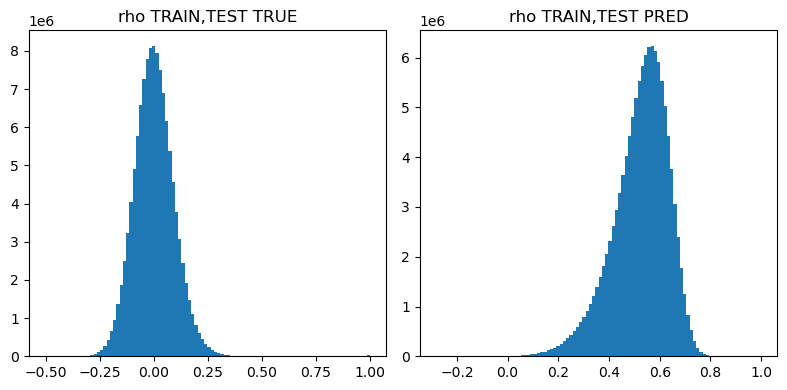

[[ 0.09272119  0.02038341 -0.01690943 ... -0.08343428  0.03668971
   0.01126367]
 [-0.04628544  0.04916284 -0.20968981 ...  0.00391391 -0.00923067
  -0.08752105]
 [-0.06064997  0.12425751  0.00422294 ... -0.08147049 -0.02574161
  -0.07016283]
 ...
 [-0.35317159 -0.12130574 -0.34488538 ...  0.01086779 -0.15564513
  -0.06013062]
 [ 0.00937956  0.0144891   0.06292527 ...  0.03818405 -0.09431433
   0.0103755 ]
 [-0.05930348  0.03497383  0.13547246 ...  0.02963692  0.06282905
   0.04160861]]
DEMEAN POST ANALYSES FLAG IS: False


In [6]:
train_test_true_fused = np.concatenate((train_truth_holder,test_truth_holder), axis=0)
train_test_pred_fused = np.concatenate((train_pred_holder,test_pred_holder), axis=0)
print(train_test_true_fused.shape)
true_train_true_test_rho = np.corrcoef(train_test_true_fused)
print(true_train_true_test_rho.shape)

print(train_test_pred_fused.shape)
pred_train_pred_test_rho = np.corrcoef(train_test_pred_fused)
print(pred_train_pred_test_rho.shape)
print(pred_train_pred_test_rho[:10])

# print(f"Train-Test_true_rho: {true_train_true_test_groundtruth_rho}")
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes = axes.flatten()
# img0 = axes[0].imshow(true_train_true_test_rho, aspect='auto', vmax=1, cmap="Spectral_r")
axes[0].hist(mat2vector(true_train_true_test_rho, diagonal_flag=1), bins=100) #including diagonal 1s
axes[0].set_title("rho TRAIN,TEST TRUE")
# plt.colorbar(img0, ax=axes[0])
# img1 = axes[1].imshow(pred_train_pred_test_rho, aspect='auto', vmax=1, cmap="Spectral_r")
# plt.colorbar(img1, ax=axes[1])
axes[1].hist(mat2vector(pred_train_pred_test_rho, diagonal_flag=1), bins=100) #including diagonal 1s
axes[1].set_title("rho TRAIN,TEST PRED")
plt.tight_layout()
plt.show()

# demean when needed
print(train_pred_holder)
if "demean" in version: #pred demean data already, so no need to demean further
    demean_flag = False
    print(f"DEMEAN POST ANALYSES FLAG IS: {demean_flag}")
    train_true_mean = 0
    train_pred_mean = 0
    test_true_mean = 0
    test_pred_mean = 0
else:
    demean_flag = True
    print(f"DEMEAN POST ANALYSES FLAG IS: {demean_flag}")
    train_true_mean = np.nanmean(train_truth_holder, axis=0, keepdims=True)
    train_pred_mean = np.nanmean(train_pred_holder, axis=0, keepdims=True)
    test_true_mean = np.nanmean(test_truth_holder, axis=0, keepdims=True)
    test_pred_mean = np.nanmean(test_pred_holder, axis=0, keepdims=True)

train_truth_holder = train_truth_holder - train_true_mean
train_pred_holder = train_pred_holder - train_pred_mean
test_truth_holder = test_truth_holder - test_true_mean
test_pred_holder = test_pred_holder - test_pred_mean

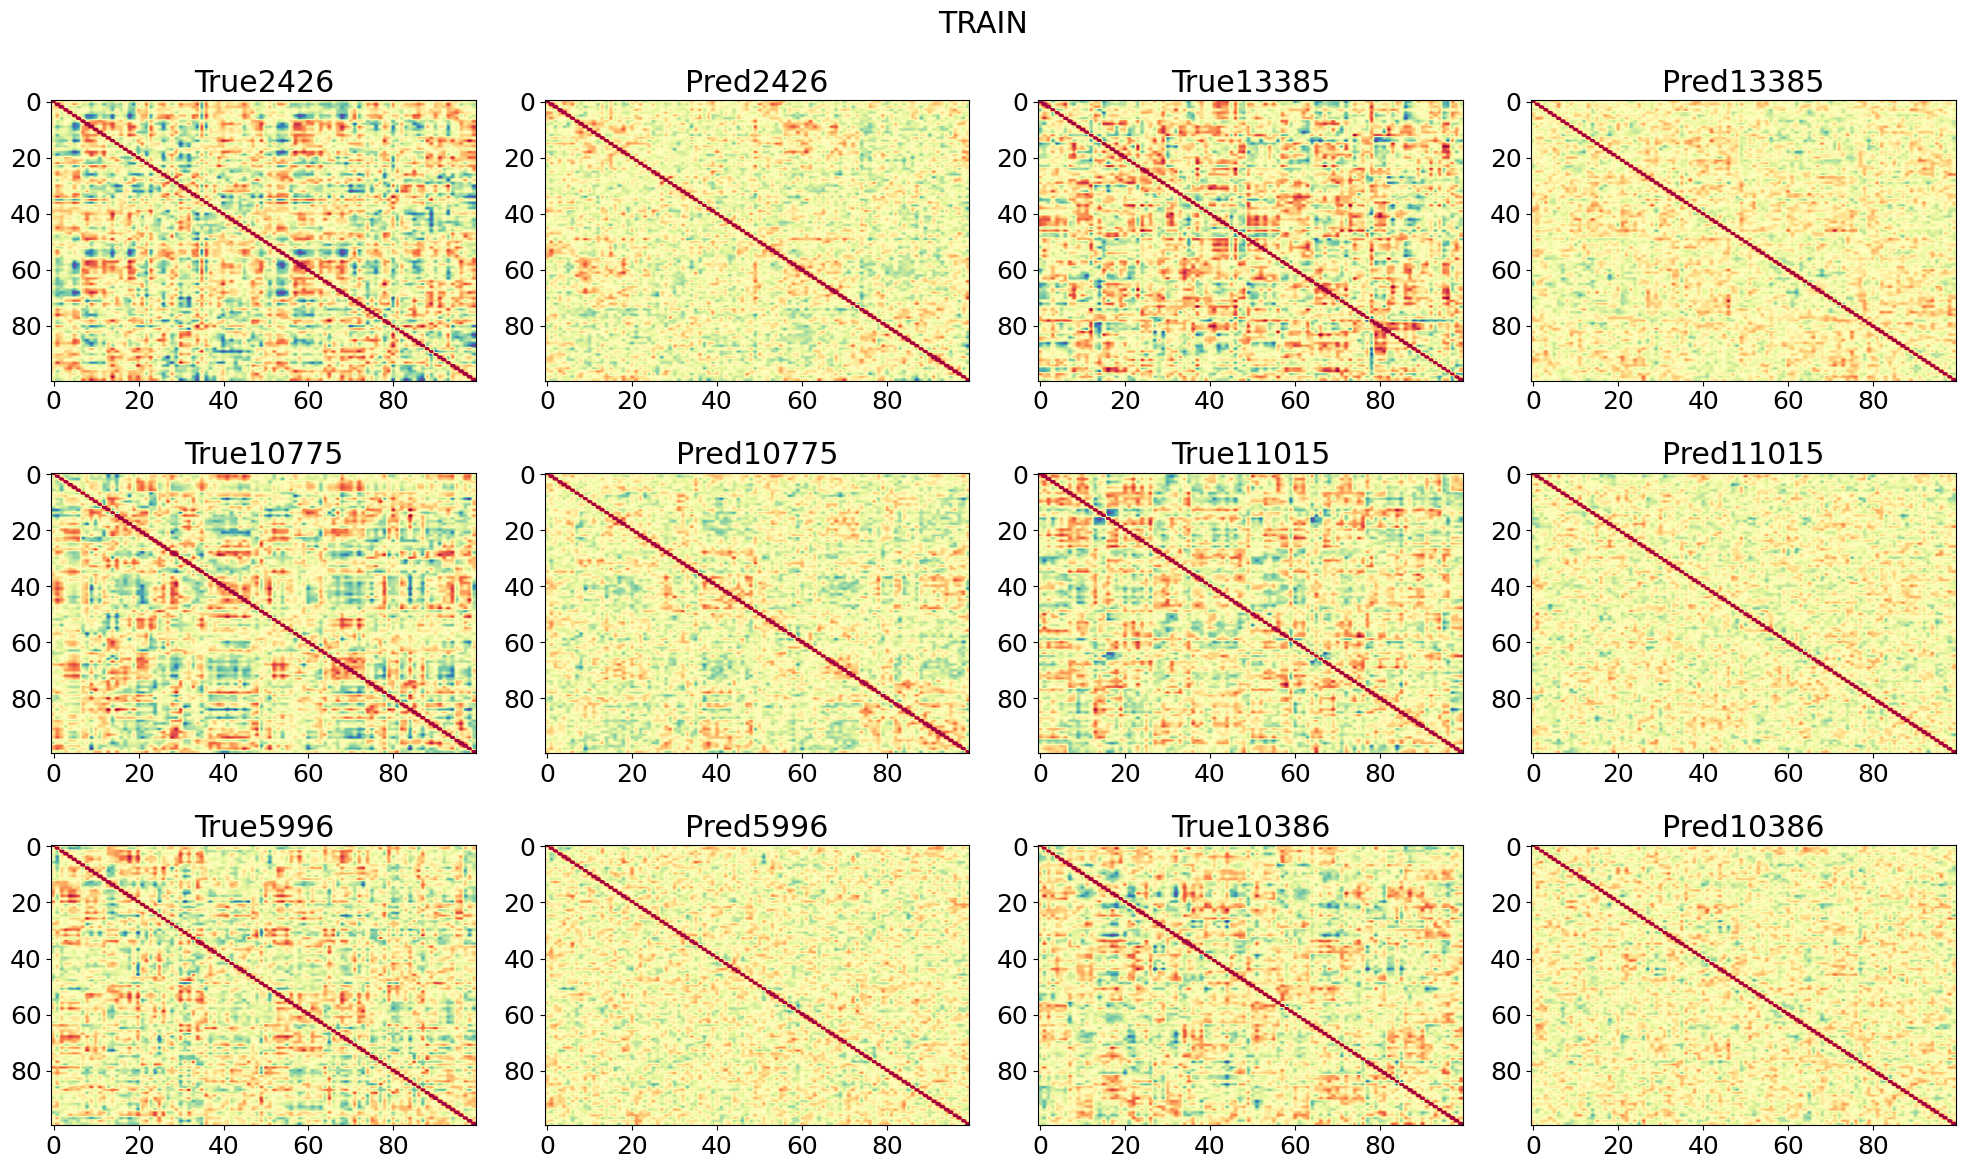

Directory for model output already exists.


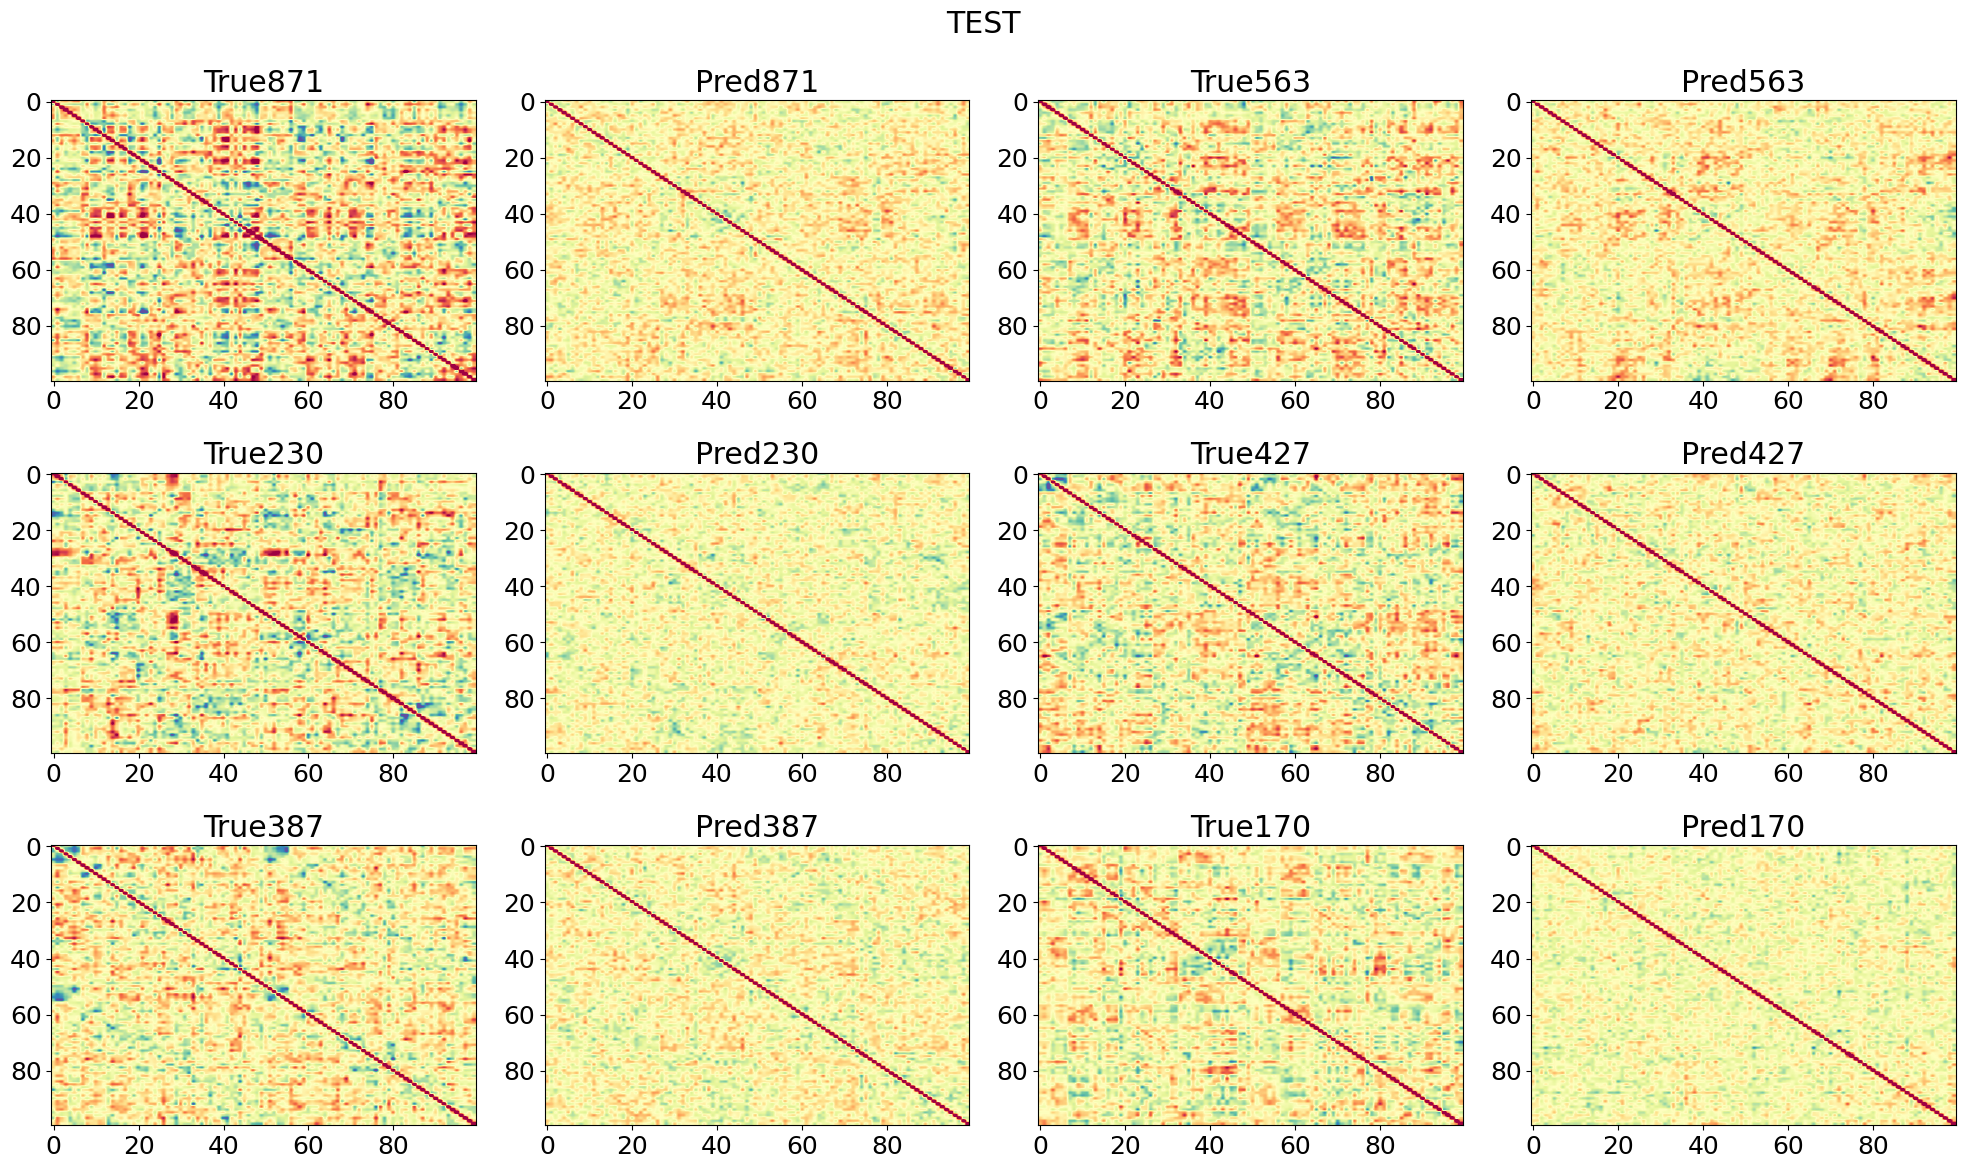

In [7]:
# visualize to again make sure all looks good
a = make_nemat_allsubj(train_truth_holder,from_parcellation)
b = make_nemat_allsubj(train_pred_holder,from_parcellation)
c = make_nemat_allsubj(test_truth_holder,from_parcellation)
d = make_nemat_allsubj(test_pred_holder,from_parcellation)

plt.rcParams.update({'font.size': 18})

# subs2view = [0, 100, 200, 300, 500, 700]
subs2view=[]
for kk in range(6):
    x = np.random.randint(0,a.shape[0])
    subs2view.append(x)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
xx = 0
for i in range(6):
    axes[xx].imshow(a[subs2view[i]].squeeze(), aspect="auto", vmin=-0.5, vmax=0.5, cmap="Spectral_r")
    axes[xx].set_title(f"True{subs2view[i]}")
    axes[xx+1].imshow(b[subs2view[i]].squeeze(), aspect="auto", vmin=-0.5, vmax=0.5, cmap="Spectral_r")
    axes[xx+1].set_title(f"Pred{subs2view[i]}")

    xx += 2
plt.suptitle("TRAIN")
plt.tight_layout()
# plt.show()

filename = f"/examples_netmats_train.{img_extension}"
# print(f"Saving to path:{directory}")
# Save the figure
# plt.savefig(directory + filename, format=img_extension)
plt.show()
plt.close()

# subs2view = [0, 5, 10, 20, 30, 40]
subs2view=[]
for kk in range(6):
    x = np.random.randint(0,c.shape[0])
    subs2view.append(x)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
xx = 0
for i in range(6):
    axes[xx].imshow(c[subs2view[i]].squeeze(), aspect="auto", vmin=-0.5, vmax=0.5, cmap="Spectral_r")
    axes[xx].set_title(f"True{subs2view[i]}")
    axes[xx+1].imshow(d[subs2view[i]].squeeze(), aspect="auto", vmin=-0.5, vmax=0.5, cmap="Spectral_r")
    axes[xx+1].set_title(f"Pred{subs2view[i]}")

    xx += 2
plt.suptitle("TEST")
plt.tight_layout()

if not os.path.exists(directory):
    os.makedirs(directory)
    print("Directory for model created.")
else:
    print("Directory for model output already exists.")

filename = f"/examples_netmats_test.{img_extension}"
# plt.savefig(directory + filename, format=img_extension)
plt.show()
plt.close()

In [8]:

# behv_of_interest="nc_y_nihtb__comp__fluid__uncor_score"
# behv_type="Fluid"

# behv_of_interest="nc_y_nihtb__comp__crystal__uncor_score"
# behv_type="Crystal"

# behv_of_interest="nc_y_nihtb__comp__tot__uncor_score"
# behv_type="Total"

# behv_of_interest="nc_y_nihtb__flnkr__uncor_score"
# behv_type="Flnkr"

# behv_of_interest="nc_y_nihtb__lswmt__uncor_score"
# behv_type="LSWMT

# behv_of_interest="nc_y_nihtb__readr__uncor_score"
# behv_type="Readoral"


Behv path file is: /Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/ABCD_behv/nc_y_nihtb.tsv
Current behv of interest being visualized: nc_y_nihtb__comp__cryst__uncor_score
Directory for model output already exists.
(37308, 2)
(26550, 2)
Removed 10758 subjects with NaNs in either crystal or fluid intelligence.
Unique behv IDs: 11811, example: ['sub-00BD7VDC' 'sub-00CY2MDM'], type<class 'numpy.ndarray'>
Removed sub- so len should be the same 11811 and example is therefore:['00BD7VDC' '00CY2MDM']
Train subjects to be used, have brain data: 
7121
Train actual IDs extracted. len:7121 and example ['003RTV85', '007W6H7B']
Test subjects to be used, have brain data: 
624
Test actual IDs extracted. len:624 and example ['00HEV6HB', '00UMK5VC']
mask for match between subject IDs with behv data and model subjects TRAIN-->7086
00CY2MDM (7086,)
mask for match between subject IDs with behv data and model subjects TEST--

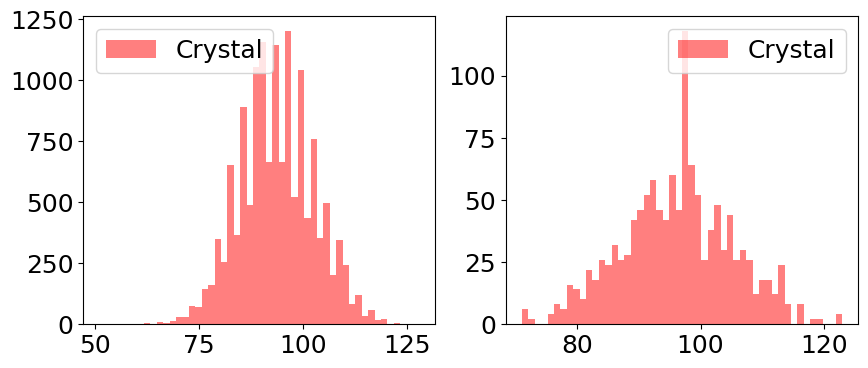

(1244, 4950) (1244, 4950)
(1, 4950)
[[ 0.0145646   0.02386228 -0.03336022 ...  0.01441089  0.02474365
  -0.00096896]] (1, 4950)
[[0.60780446 0.40040099 0.23968589 ... 0.61159849 0.38322254 0.9727644 ]]
[[0.60780446 0.40040099 0.23968589 ... 0.61159849 0.38322254 0.9727644 ]]
[[0.73514809 0.54011807 0.80880138 ... 0.37912761 0.3605945  0.76099085]]
[[0.73514809 0.54011807 0.80880138 ... 0.37912761 0.3605945  0.76099085]]
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


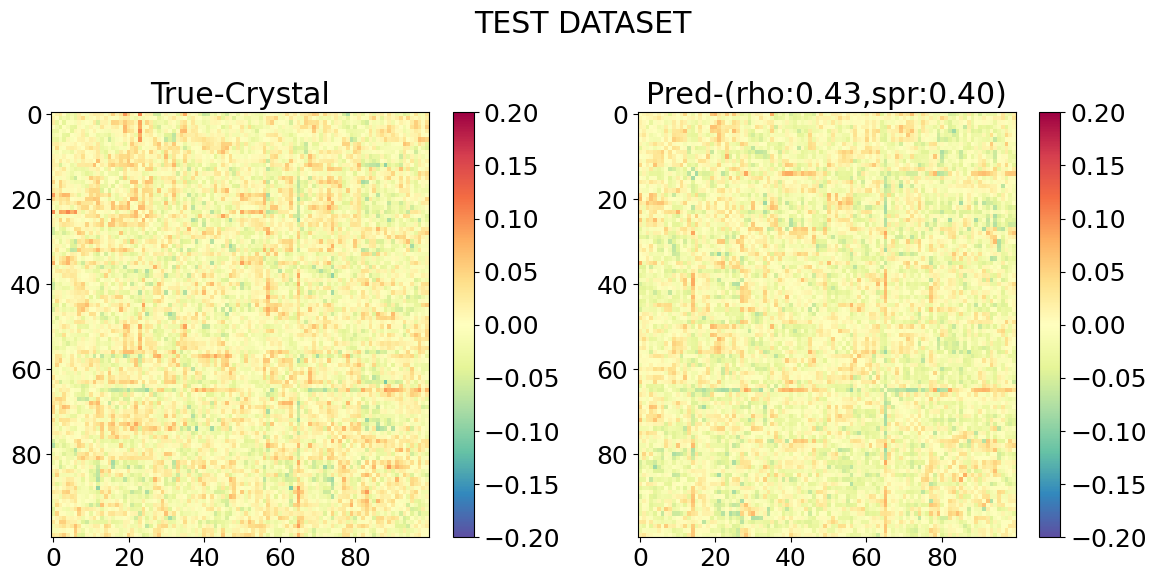

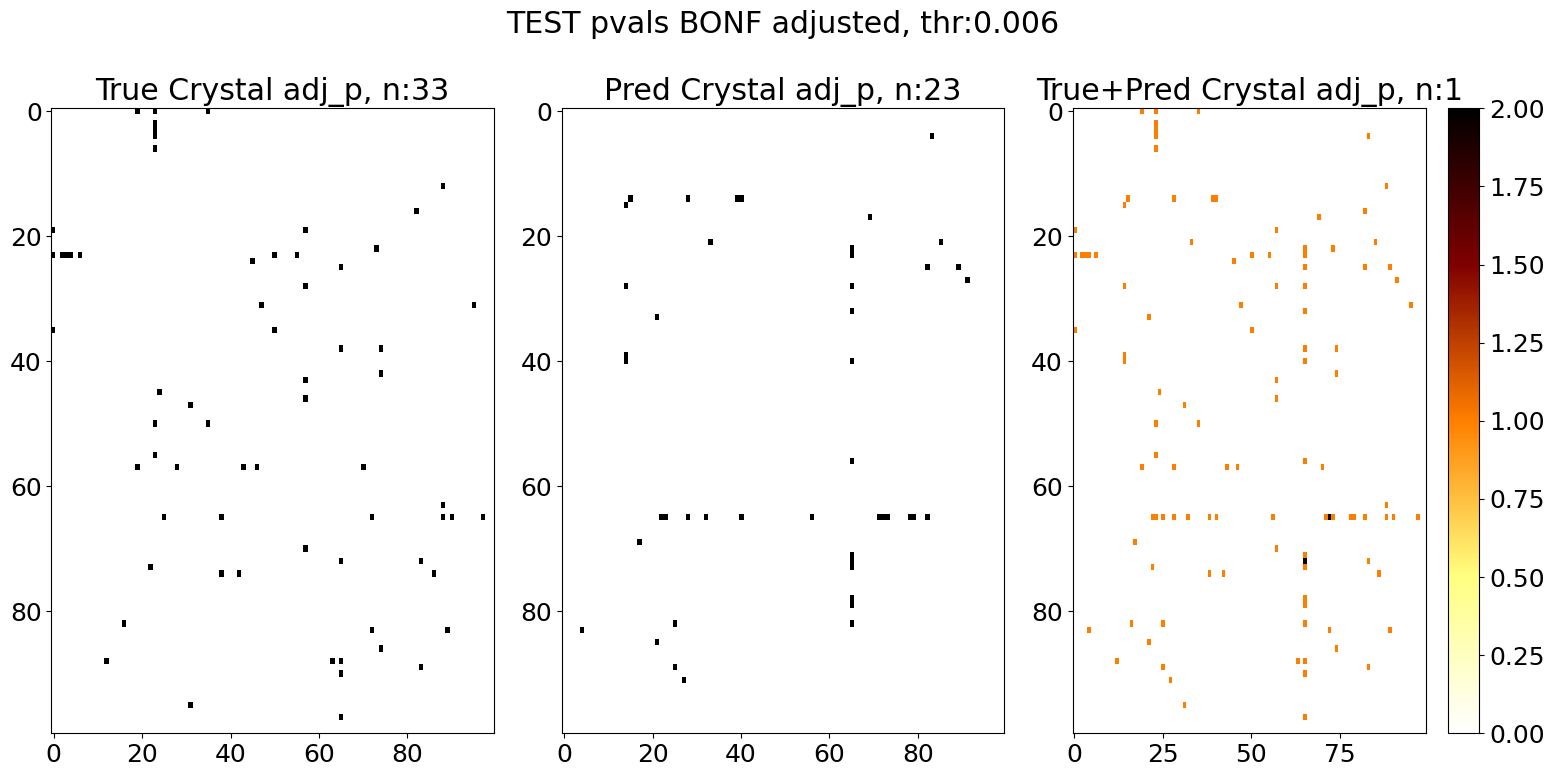

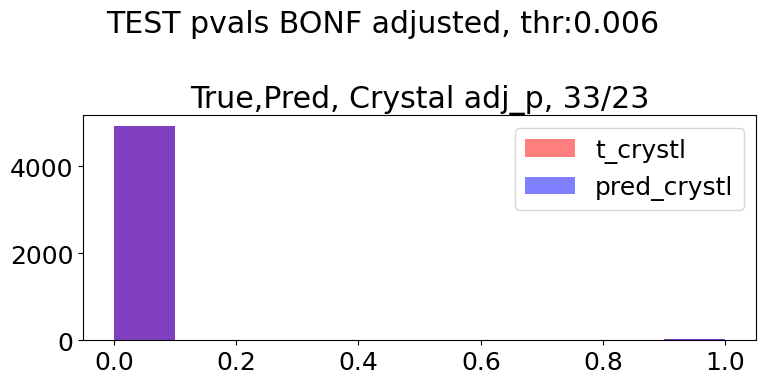

Behv path file is: /Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/ABCD_behv/nc_y_nihtb.tsv
Current behv of interest being visualized: nc_y_nihtb__comp__fluid__uncor_score
Directory for model created.
(37308, 2)
(15483, 2)
Removed 21825 subjects with NaNs in either crystal or fluid intelligence.
Unique behv IDs: 11694, example: ['sub-00BD7VDC' 'sub-00CY2MDM'], type<class 'numpy.ndarray'>
Removed sub- so len should be the same 11694 and example is therefore:['00BD7VDC' '00CY2MDM']
Train subjects to be used, have brain data: 
7121
Train actual IDs extracted. len:7121 and example ['003RTV85', '007W6H7B']
Test subjects to be used, have brain data: 
624
Test actual IDs extracted. len:624 and example ['00HEV6HB', '00UMK5VC']
mask for match between subject IDs with behv data and model subjects TRAIN-->7016
00CY2MDM (7016,)
mask for match between subject IDs with behv data and model subjects TEST-->622
00HEV6HB 

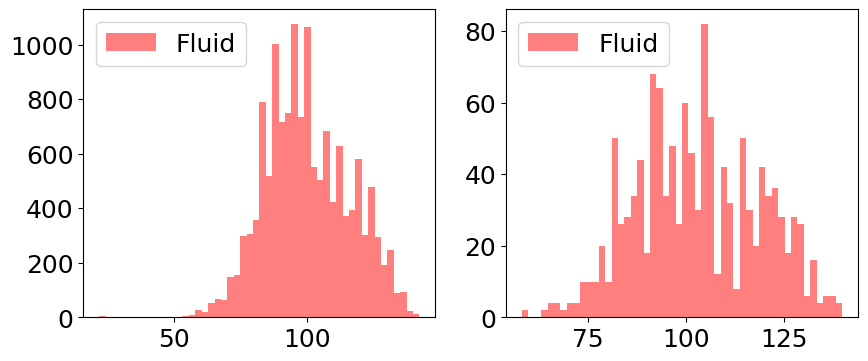

(1244, 4950) (1244, 4950)
(1, 4950)
[[-0.00266597 -0.02046646 -0.03835579 ...  0.01838135  0.02019363
  -0.02726953]] (1, 4950)
[[0.92516056 0.4707804  0.17638781 ... 0.51716594 0.47671636 0.33654286]]
[[0.92516056 0.4707804  0.17638781 ... 0.51716594 0.47671636 0.33654286]]
[[0.93511995 0.29666939 0.38886725 ... 0.22212927 0.92413593 0.48816692]]
[[0.93511995 0.29666939 0.38886725 ... 0.22212927 0.92413593 0.48816692]]
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


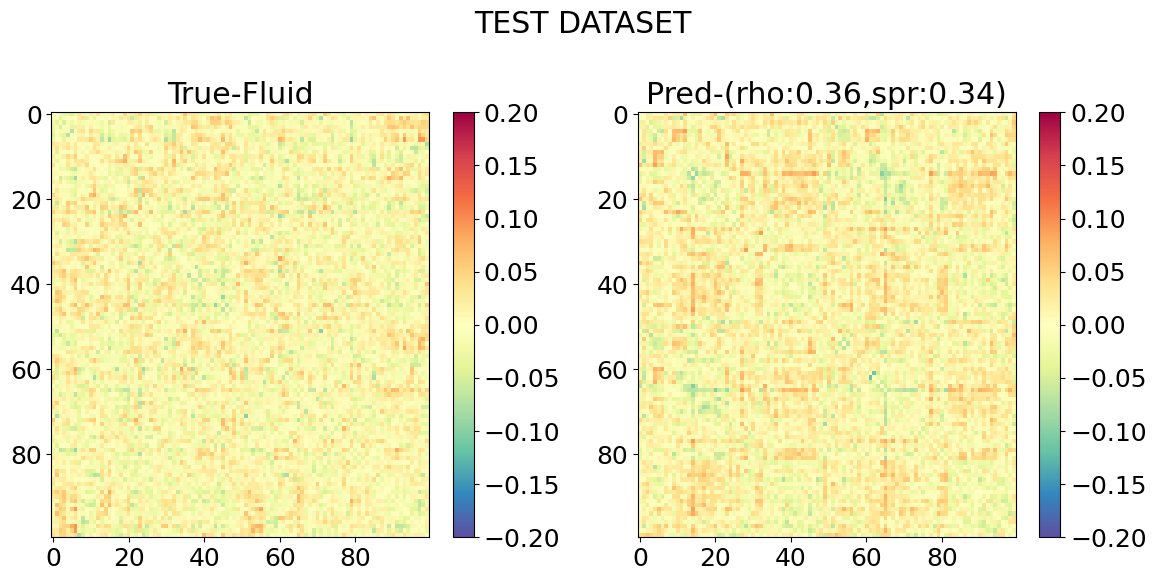

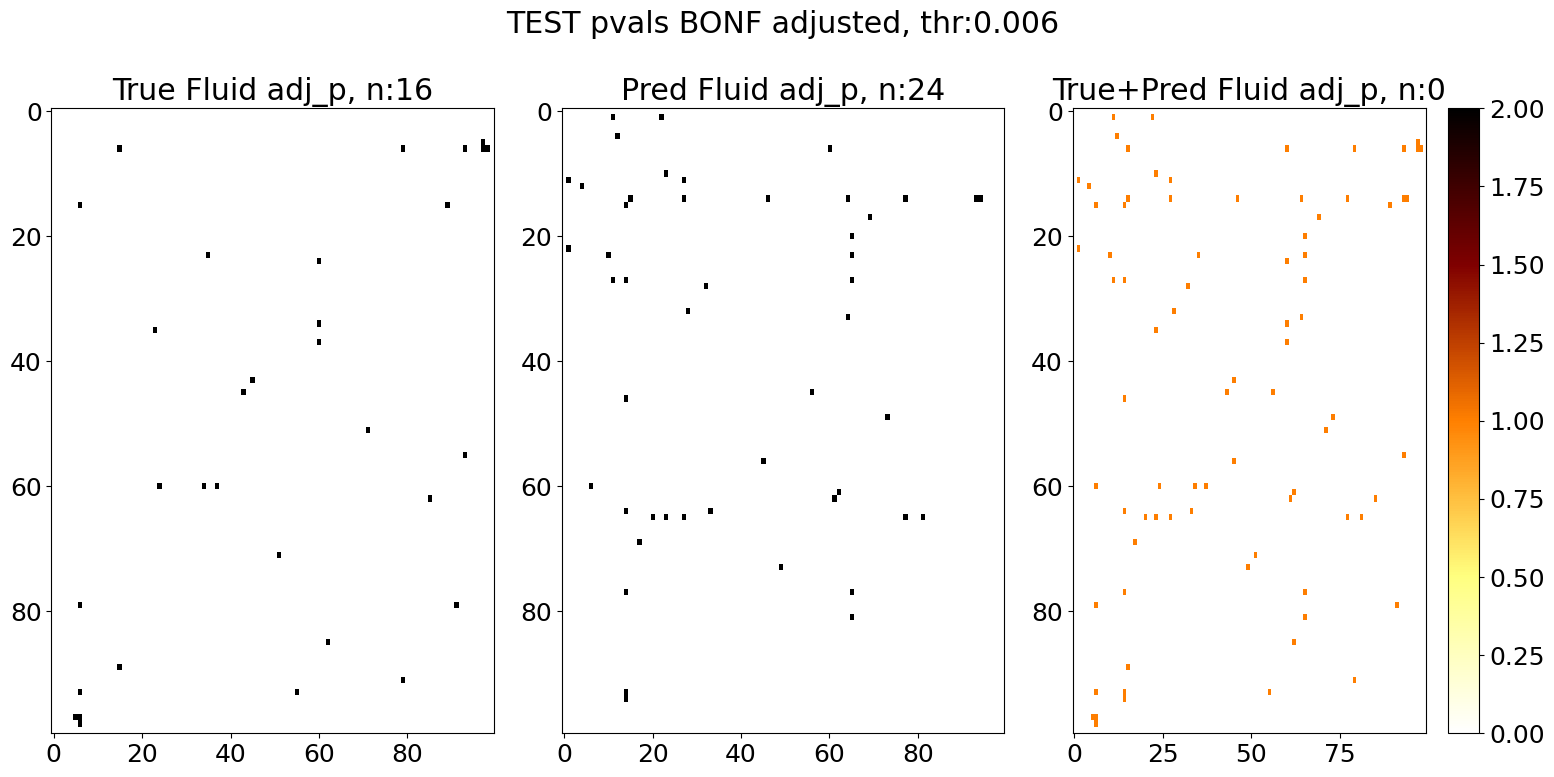

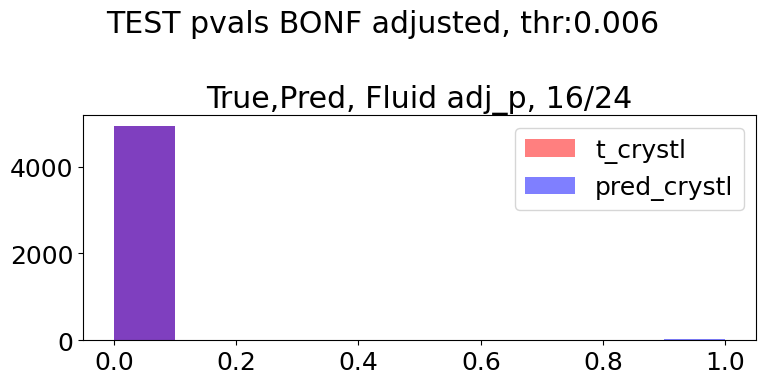

Behv path file is: /Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/ABCD_behv/nc_y_nihtb.tsv
Current behv of interest being visualized: nc_y_nihtb__comp__tot__uncor_score
Directory for model created.
(37308, 2)
(15452, 2)
Removed 21856 subjects with NaNs in either crystal or fluid intelligence.
Unique behv IDs: 11693, example: ['sub-00BD7VDC' 'sub-00CY2MDM'], type<class 'numpy.ndarray'>
Removed sub- so len should be the same 11693 and example is therefore:['00BD7VDC' '00CY2MDM']
Train subjects to be used, have brain data: 
7121
Train actual IDs extracted. len:7121 and example ['003RTV85', '007W6H7B']
Test subjects to be used, have brain data: 
624
Test actual IDs extracted. len:624 and example ['00HEV6HB', '00UMK5VC']
mask for match between subject IDs with behv data and model subjects TRAIN-->7015
00CY2MDM (7015,)
mask for match between subject IDs with behv data and model subjects TEST-->621
00HEV6HB (6

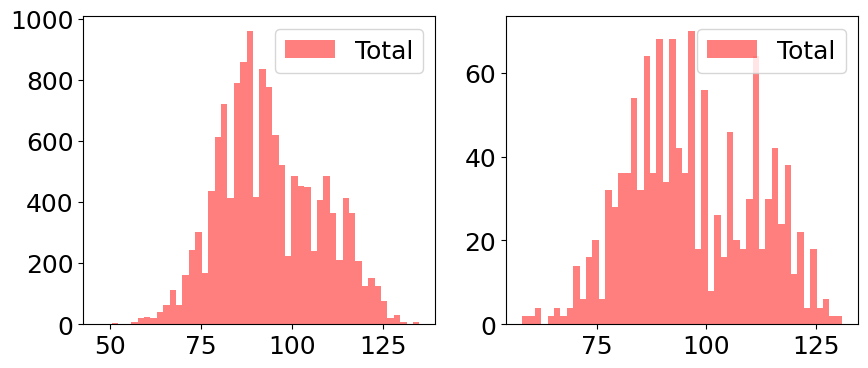

(1242, 4950) (1242, 4950)
(1, 4950)
[[-0.00289942 -0.01156442 -0.04162906 ...  0.01296758  0.01940511
  -0.02917398]] (1, 4950)
[[0.91869411 0.68389273 0.14258006 ... 0.64798532 0.49444821 0.30426343]]
[[0.91869411 0.68389273 0.14258006 ... 0.64798532 0.49444821 0.30426343]]
[[0.98263423 0.41276761 0.38262569 ... 0.17619153 0.76069923 0.4878026 ]]
[[0.98263423 0.41276761 0.38262569 ... 0.17619153 0.76069923 0.4878026 ]]
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


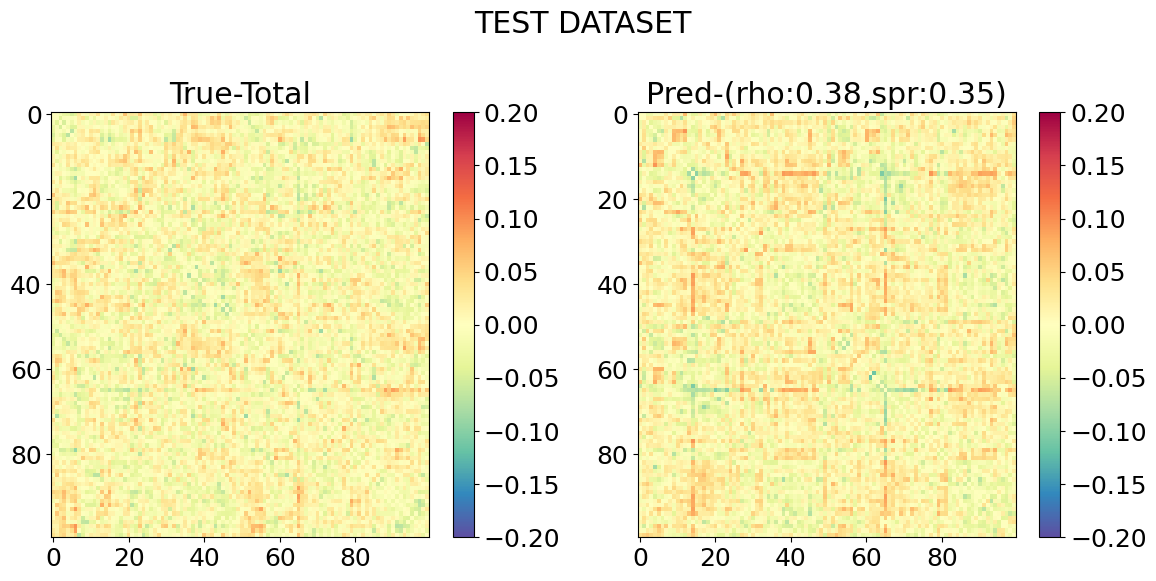

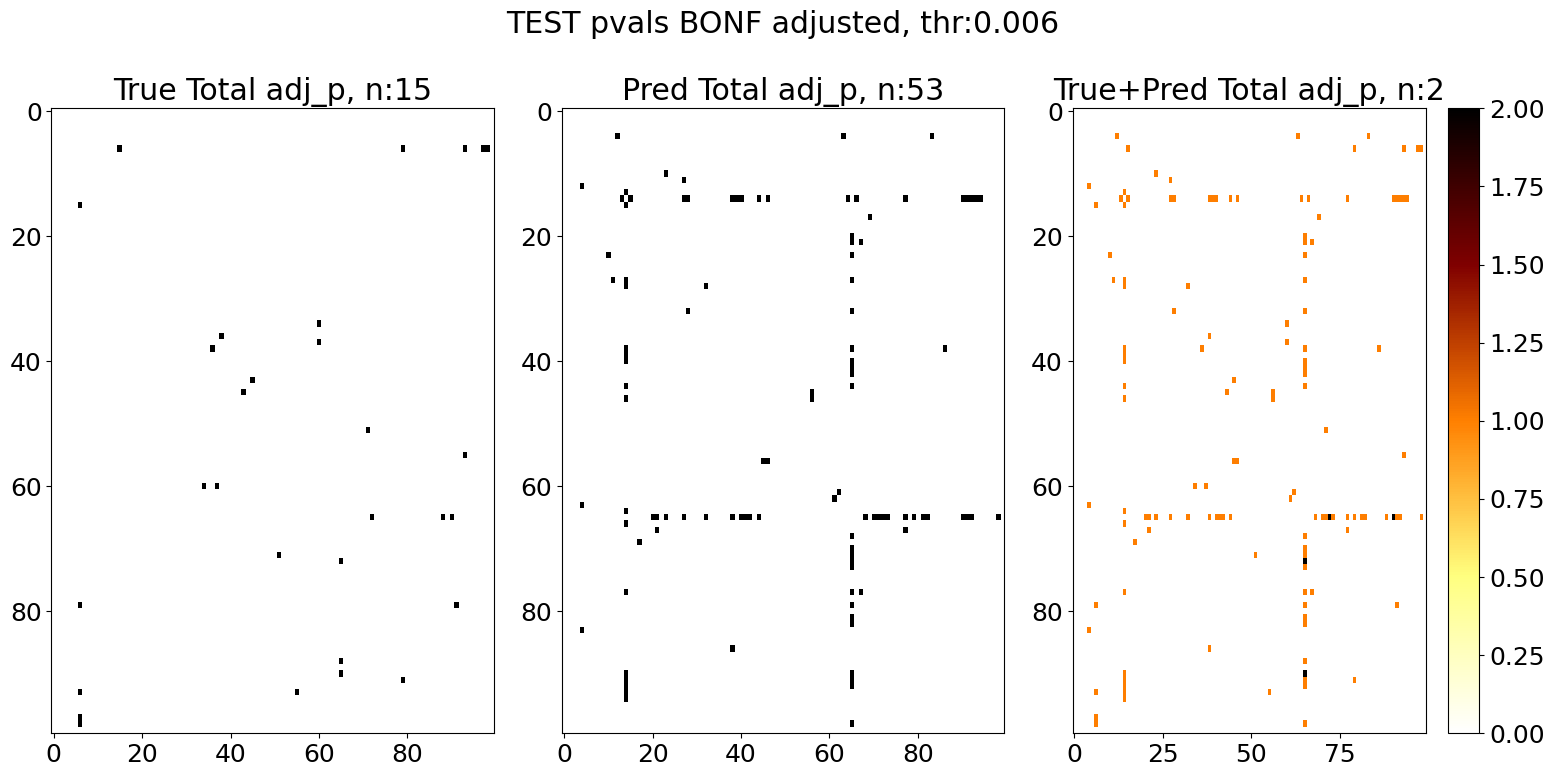

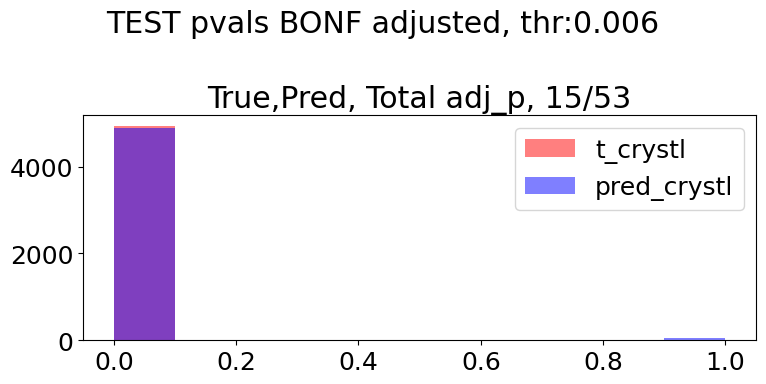

Behv path file is: /Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/ABCD_behv/nc_y_nihtb.tsv
Current behv of interest being visualized: nc_y_nihtb__flnkr__uncor_score
Directory for model created.
(37308, 2)
(31767, 2)
Removed 5541 subjects with NaNs in either crystal or fluid intelligence.
Unique behv IDs: 11841, example: ['sub-00BD7VDC' 'sub-00CY2MDM'], type<class 'numpy.ndarray'>
Removed sub- so len should be the same 11841 and example is therefore:['00BD7VDC' '00CY2MDM']
Train subjects to be used, have brain data: 
7121
Train actual IDs extracted. len:7121 and example ['003RTV85', '007W6H7B']
Test subjects to be used, have brain data: 
624
Test actual IDs extracted. len:624 and example ['00HEV6HB', '00UMK5VC']
mask for match between subject IDs with behv data and model subjects TRAIN-->7105
00CY2MDM (7105,)
mask for match between subject IDs with behv data and model subjects TEST-->624
00HEV6HB (624,)


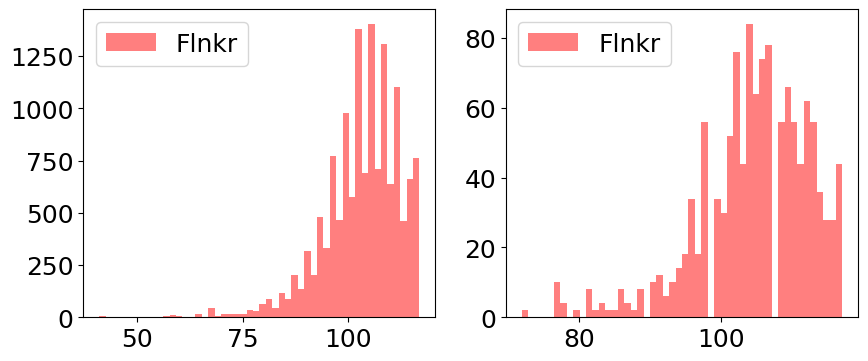

(1248, 4950) (1248, 4950)
(1, 4950)
[[ 0.00506305  0.03826656 -0.03775503 ...  0.03734483  0.00842526
  -0.04138864]] (1, 4950)
[[0.85818539 0.17670031 0.18256064 ... 0.18736295 0.76620194 0.1439333 ]]
[[0.85818539 0.17670031 0.18256064 ... 0.18736295 0.76620194 0.1439333 ]]
[[0.48857825 0.94731418 0.65689494 ... 0.37384868 0.94212323 0.26084651]]
[[0.48857825 0.94731418 0.65689494 ... 0.37384868 0.94212323 0.26084651]]
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


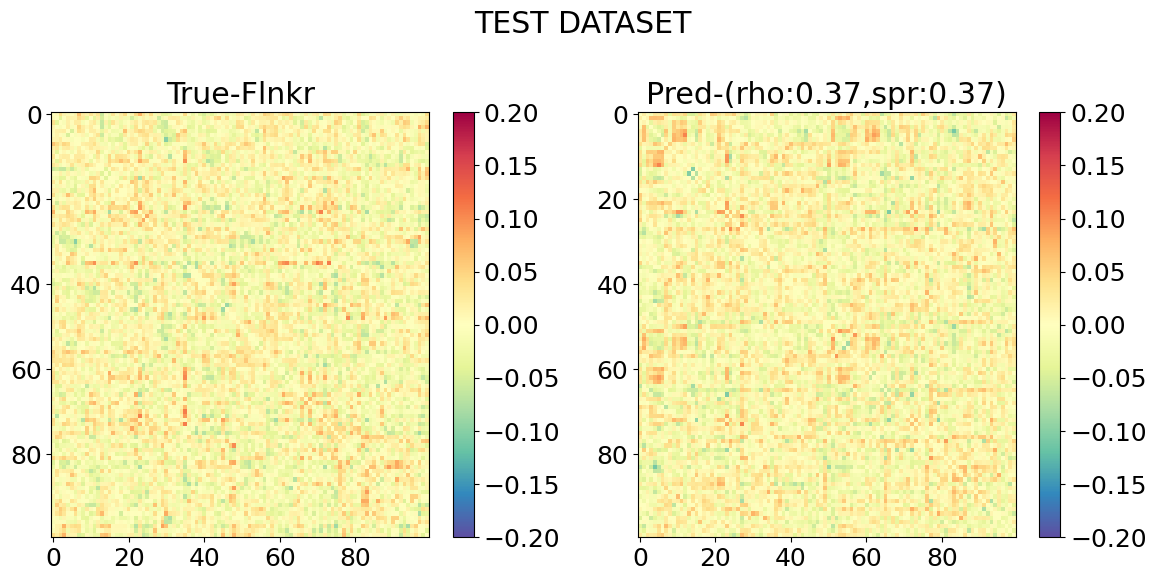

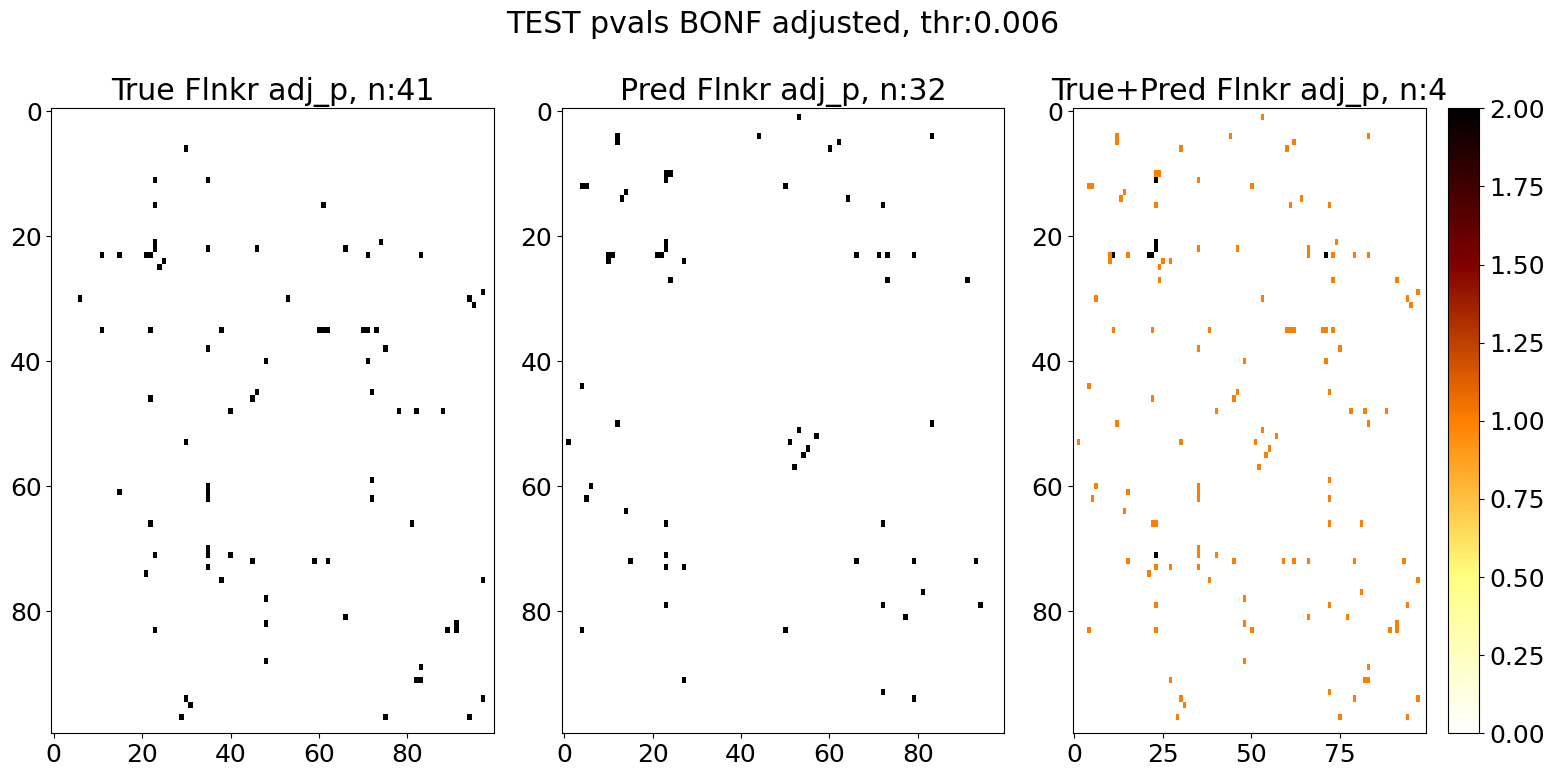

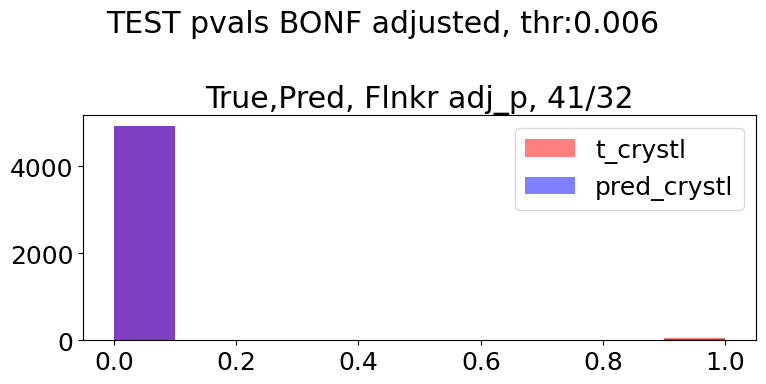

Behv path file is: /Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/ABCD_behv/nc_y_nihtb.tsv
Current behv of interest being visualized: nc_y_nihtb__lswmt__uncor_score
Directory for model created.
(37308, 2)
(25842, 2)
Removed 11466 subjects with NaNs in either crystal or fluid intelligence.
Unique behv IDs: 11826, example: ['sub-00BD7VDC' 'sub-00CY2MDM'], type<class 'numpy.ndarray'>
Removed sub- so len should be the same 11826 and example is therefore:['00BD7VDC' '00CY2MDM']
Train subjects to be used, have brain data: 
7121
Train actual IDs extracted. len:7121 and example ['003RTV85', '007W6H7B']
Test subjects to be used, have brain data: 
624
Test actual IDs extracted. len:624 and example ['00HEV6HB', '00UMK5VC']
mask for match between subject IDs with behv data and model subjects TRAIN-->7095
00CY2MDM (7095,)
mask for match between subject IDs with behv data and model subjects TEST-->623
00HEV6HB (623,)

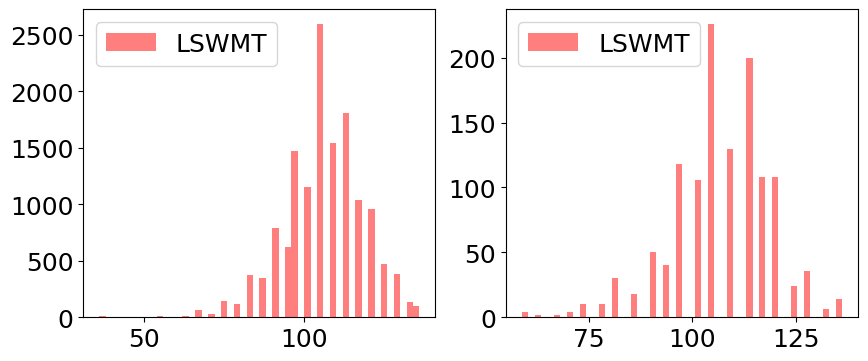

(1246, 4950) (1246, 4950)
(1, 4950)
[[ 0.01085793  0.0104936  -0.02523153 ...  0.03106853 -0.00367242
  -0.01513769]] (1, 4950)
[[0.7017957  0.71134591 0.37352568 ... 0.27314737 0.89696047 0.59345537]]
[[0.7017957  0.71134591 0.37352568 ... 0.27314737 0.89696047 0.59345537]]
[[0.75585256 0.19689584 0.43626993 ... 0.51672864 0.37195534 0.50806666]]
[[0.75585256 0.19689584 0.43626993 ... 0.51672864 0.37195534 0.50806666]]
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


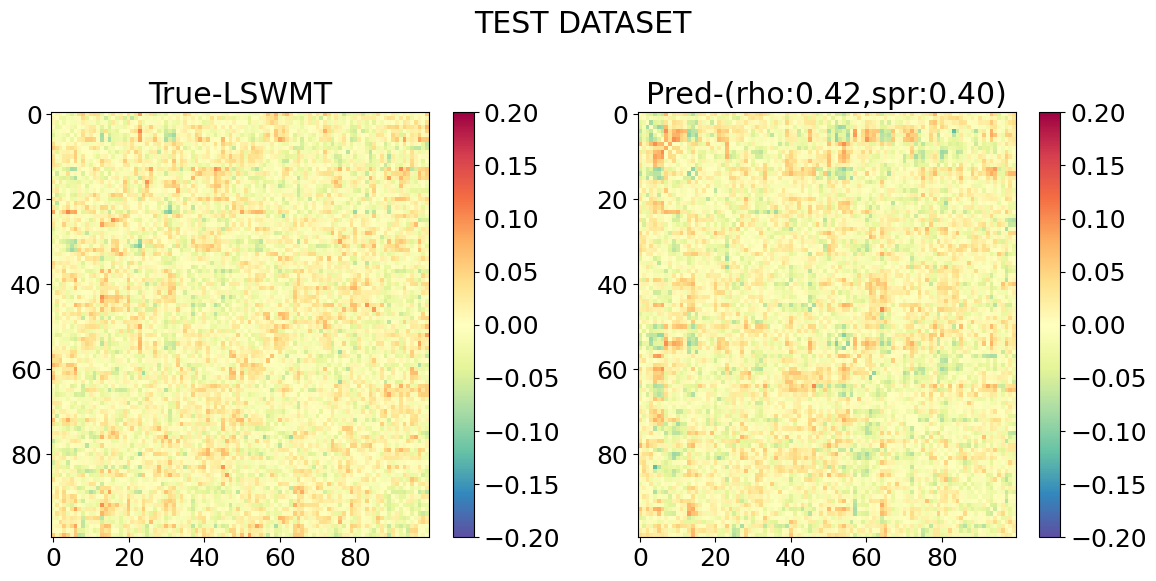

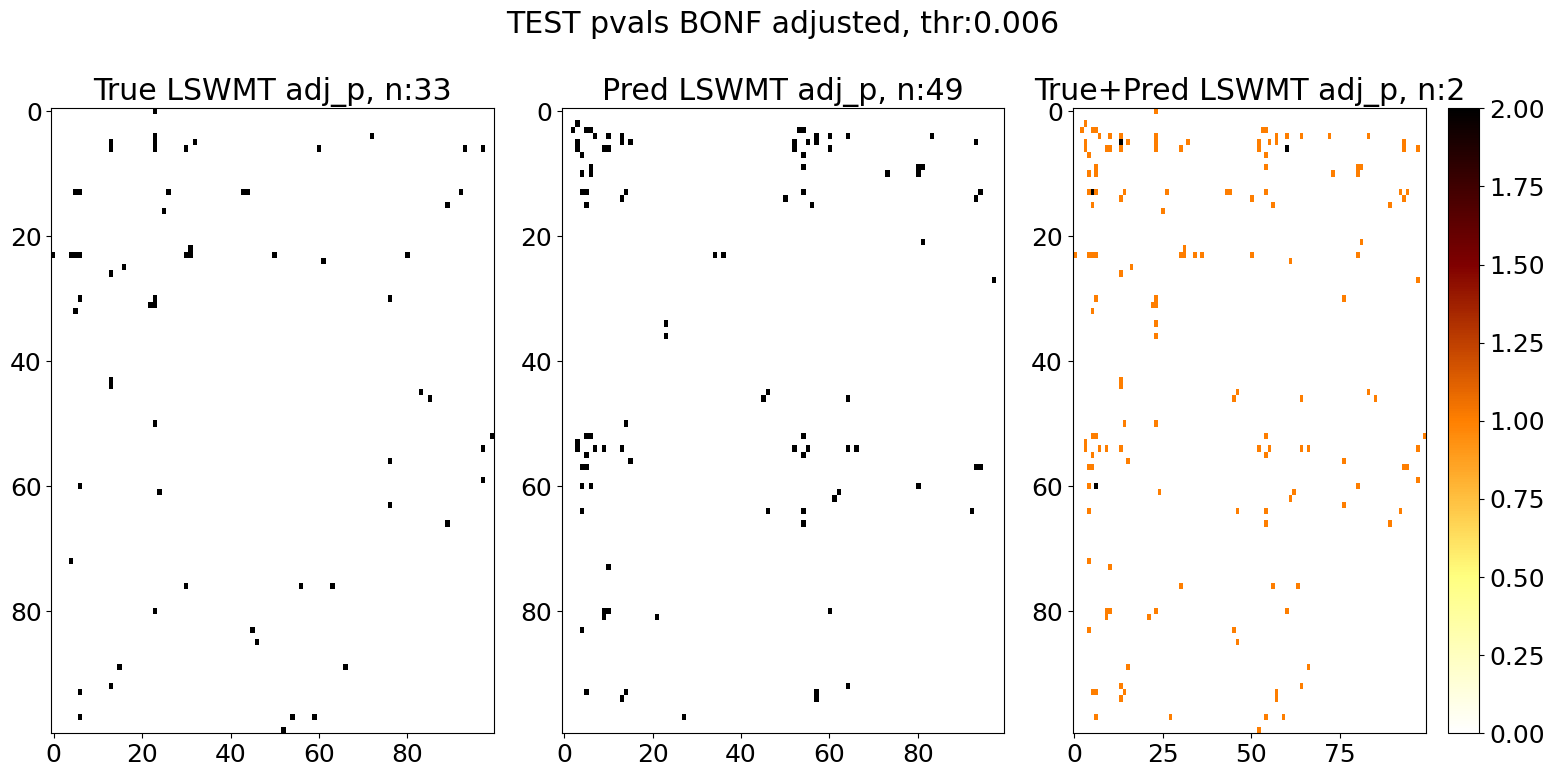

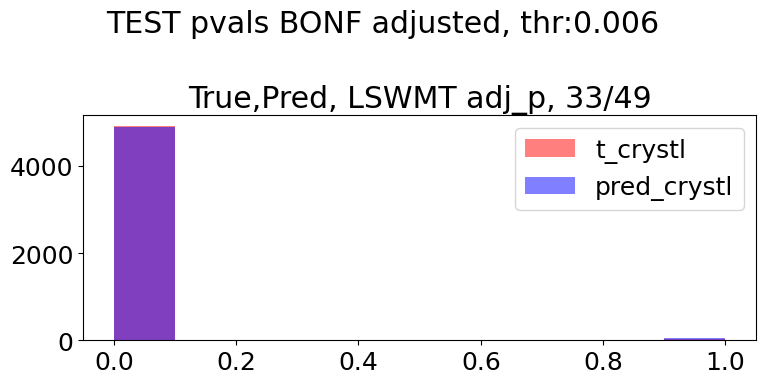

Behv path file is: /Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/ABCD_behv/nc_y_nihtb.tsv
Current behv of interest being visualized: nc_y_nihtb__readr__uncor_score
Directory for model created.
(37308, 2)
(36167, 2)
Removed 1141 subjects with NaNs in either crystal or fluid intelligence.
Unique behv IDs: 11848, example: ['sub-00BD7VDC' 'sub-00CY2MDM'], type<class 'numpy.ndarray'>
Removed sub- so len should be the same 11848 and example is therefore:['00BD7VDC' '00CY2MDM']
Train subjects to be used, have brain data: 
7121
Train actual IDs extracted. len:7121 and example ['003RTV85', '007W6H7B']
Test subjects to be used, have brain data: 
624
Test actual IDs extracted. len:624 and example ['00HEV6HB', '00UMK5VC']
mask for match between subject IDs with behv data and model subjects TRAIN-->7108
00CY2MDM (7108,)
mask for match between subject IDs with behv data and model subjects TEST-->624
00HEV6HB (624,)


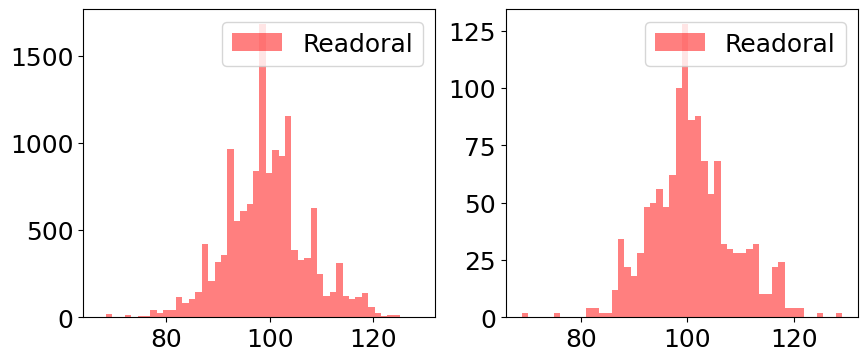

(1248, 4950) (1248, 4950)
(1, 4950)
[[ 0.01276571  0.03828252 -0.01811897 ... -0.00852371  0.00639885
   0.0062408 ]] (1, 4950)
[[0.65232016 0.1765198  0.52249726 ... 0.76355092 0.82133508 0.82567641]]
[[0.65232016 0.1765198  0.52249726 ... 0.76355092 0.82133508 0.82567641]]
[[0.88857642 0.39224346 0.71608727 ... 0.72132914 0.79133829 0.48204835]]
[[0.88857642 0.39224346 0.71608727 ... 0.72132914 0.79133829 0.48204835]]
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


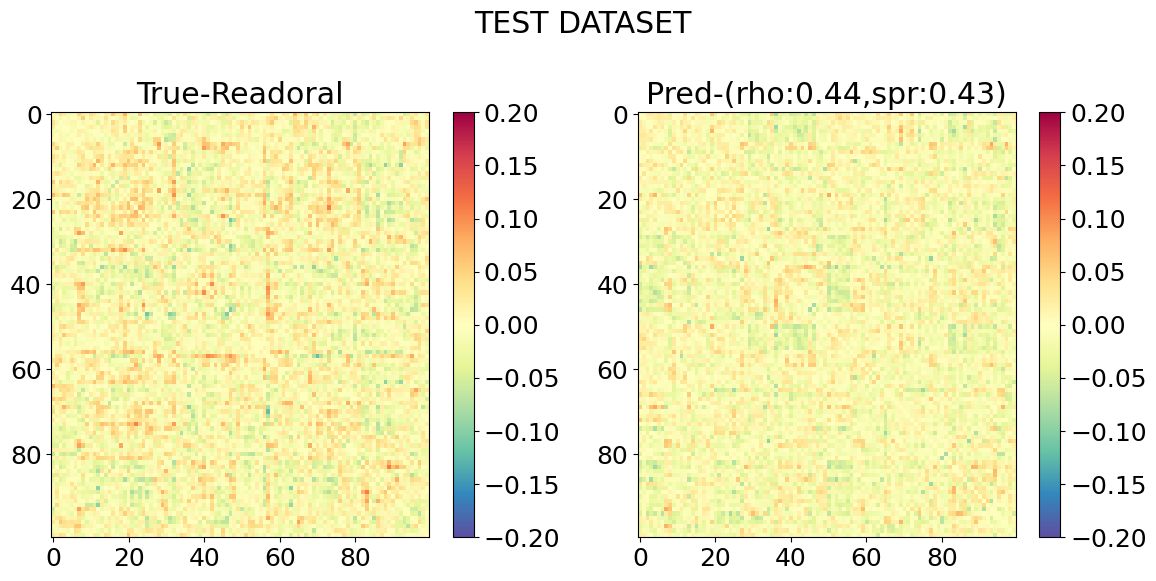

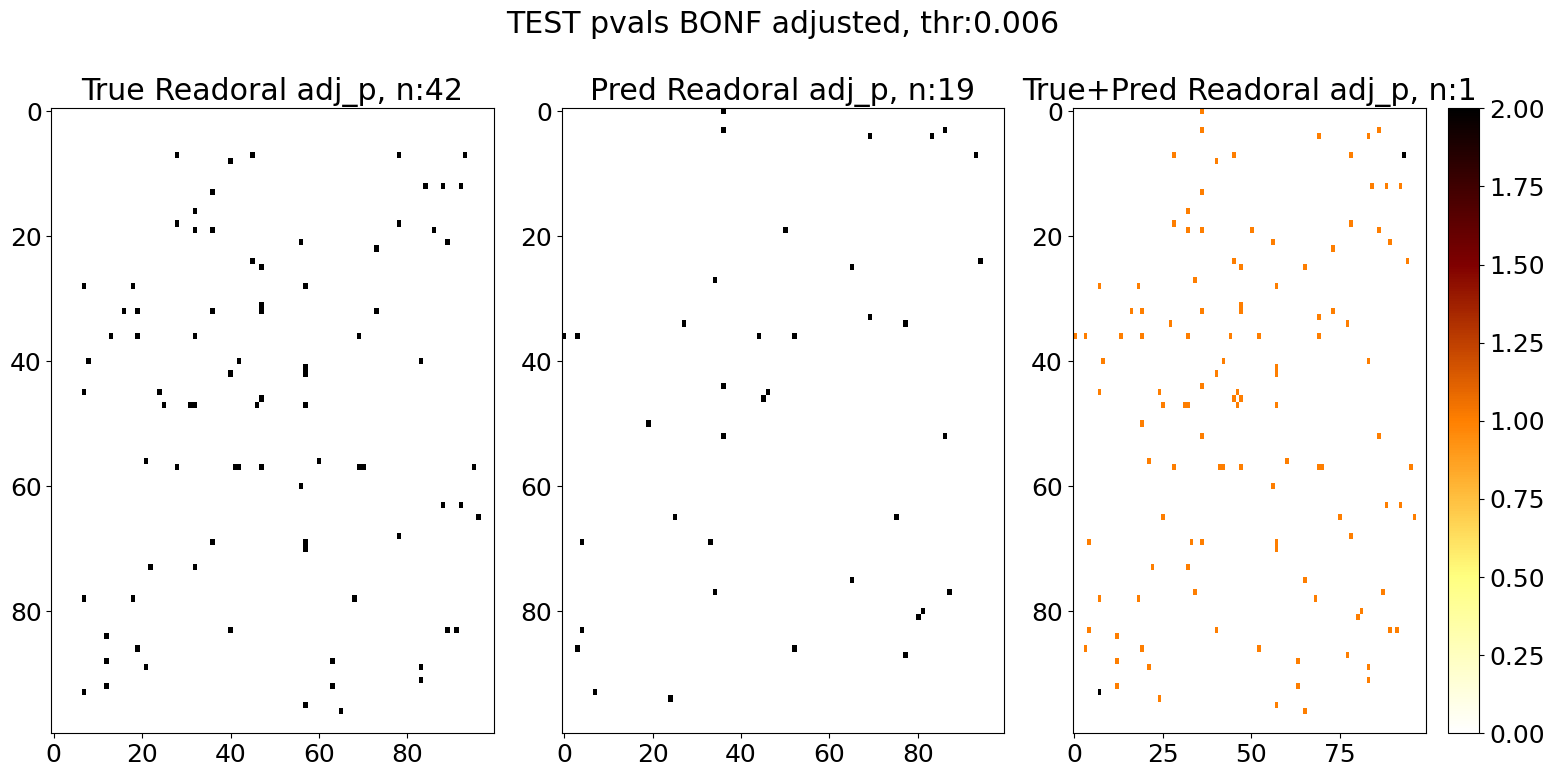

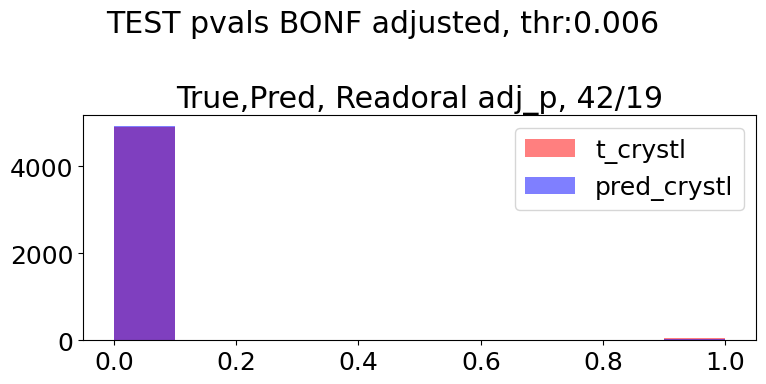

In [13]:
# ABCD behavioral measures
beh_path = f"{scratch_path}/NeuroTranslate/ABCD_behv/nc_y_nihtb.tsv"
composite_scores = pd.read_csv(beh_path)
# from scipy.stats.mstats import winsorize
behv_of_interest_list = ["nc_y_nihtb__comp__cryst__uncor_score",
                         "nc_y_nihtb__comp__fluid__uncor_score",
                         "nc_y_nihtb__comp__tot__uncor_score",
                         "nc_y_nihtb__flnkr__uncor_score",
                         "nc_y_nihtb__lswmt__uncor_score",
                         "nc_y_nihtb__readr__uncor_score"]
behv_type_list=["Crystal",
                "Fluid",
                "Total",
                "Flnkr",
                "LSWMT",
                "Readoral"]
# behv_of_interest_list = ["nc_y_nihtb__comp__cryst__uncor_score"]
# behv_type_list=["Crystal"]
for pp in range(len(behv_of_interest_list)):
    behv_of_interest=behv_of_interest_list[pp]
    print(f"Behv path file is: {beh_path}")
    print(f"Current behv of interest being visualized: {behv_of_interest}")
    behv_type=behv_type_list[pp]

    # need to reset and redefine directory so we can create in same path
    directory = root + '/images/ABCD/' + translation  + '/' + model_type +'/' + version + '/'+ model_details + '/' + model_test_type + '/downstream_analyses' #
    directory=directory+f"/{behv_type}"
    if not os.path.exists(directory):
        os.makedirs(directory)
        print("Directory for model created.")
    else:
        print("Directory for model output already exists.")

    cols_to_use_list = ["participant_id", f"{behv_of_interest}"] #nc_y_nihtb__comp__fluid__uncor_score, nc_y_nihtb__comp__cryst__uncor_score
    composite_scores = pd.read_csv(beh_path, sep='\t', usecols=cols_to_use_list) #nc_y_nihtb__comp__cryst__uncor_score, nc_y_nihtb__comp__fluid__uncor_score
    print(composite_scores.shape)
    # clean of NaNs
    composite_scores_clean = composite_scores.dropna()
    print(composite_scores_clean.shape)
    print(f"Removed {(composite_scores.shape[0] - composite_scores_clean.shape[0])} subjects with NaNs in either crystal or fluid intelligence.")

    unique_ids = composite_scores_clean["participant_id"].unique()
    print(f"Unique behv IDs: {len(unique_ids)}, example: {unique_ids[:2]}, type{type(unique_ids)}")
    unique_ids_clean = unique_ids
    for ii in range(unique_ids.shape[0]):
        unique_ids_clean[ii] = unique_ids[ii][4:]
    print(f"Removed sub- so len should be the same {len(unique_ids_clean)} and example is therefore:{unique_ids_clean[:2]}") #clean here means removed the "sub-""

    #do the same for the IDs we use in our analyses
    main_ids_path=f"{scratch_path}/NeuroTranslate/surf2netmat/utils/subj_ids/{datasets}/full_IDs_train_val_test_{hemi_cond}_connectome_{parcellation}_{from_parcellation}_{parcellation_corr_type}.csv"
    get_subIDs_groups = pd.read_csv(main_ids_path)
    ABCD_main_ids_clean=list(get_subIDs_groups[get_subIDs_groups['group'] == 'train']['sub_IDs'].unique())
    print(f"Train subjects to be used, have brain data: \n{len(ABCD_main_ids_clean)}")
    print(f"Train actual IDs extracted. len:{len(ABCD_main_ids_clean)} and example {ABCD_main_ids_clean[:2]}")

    # repeat for test
    ABCD_main_ids_test_clean=list(get_subIDs_groups[get_subIDs_groups['group'] == 'test']['sub_IDs'].unique())
    print(f"Test subjects to be used, have brain data: \n{len(ABCD_main_ids_test_clean)}")
    print(f"Test actual IDs extracted. len:{len(ABCD_main_ids_test_clean)} and example {ABCD_main_ids_test_clean[:2]}")

    # only get subjects that are in the main IDs for reference
    isin_check_mask = np.isin(unique_ids_clean, ABCD_main_ids_clean)
    # brain_data_mask_train = np.isin(ABCD_main_ids_clean,unique_ids_clean)
    print(f"mask for match between subject IDs with behv data and model subjects TRAIN-->{(isin_check_mask.sum())}")
    unique_ids_clean_unified = unique_ids_clean[isin_check_mask]
    print((unique_ids_clean_unified[0]), unique_ids_clean_unified.shape)

    isin_check_mask = np.isin(unique_ids_clean, ABCD_main_ids_test_clean)
    # brain_data_mask_test = np.isin(ABCD_main_ids_test_clean, unique_ids_clean)
    print(f"mask for match between subject IDs with behv data and model subjects TEST-->{(isin_check_mask.sum())}")
    unique_ids_clean_unified_test = unique_ids_clean[isin_check_mask] # same composite IDs file but now only using subjects that are in test
    print((unique_ids_clean_unified_test[0]), unique_ids_clean_unified_test.shape)

    bilateral_condition_flag=True
    if bilateral_condition_flag is True:
        unique_ids_clean_unified = np.concatenate((unique_ids_clean_unified,unique_ids_clean_unified), axis=0)
        unique_ids_clean_unified_test = np.concatenate((unique_ids_clean_unified_test,unique_ids_clean_unified_test), axis=0)
        print(len(unique_ids_clean_unified),len(unique_ids_clean_unified_test))
        ABCD_main_ids_clean = ABCD_main_ids_clean+ABCD_main_ids_clean
        ABCD_main_ids_test_clean= ABCD_main_ids_test_clean+ABCD_main_ids_test_clean
        print(len(ABCD_main_ids_clean), len(ABCD_main_ids_test_clean))

    subj_list_scores = []
    # below gets crystal and fluid scores for all subjects in the large composite_scores_clean file that ARE in the train_IDs AND have data (no nans)
    for ii in range(unique_ids_clean_unified.shape[0]):
        str_version_with_sub = "sub-" + f"{unique_ids_clean_unified[ii]}"
        # print(str_version_with_sub)
        curr_ii = np.where(composite_scores_clean["participant_id"] == str_version_with_sub)
        # print(curr_ii) #idx of where its at in larger composite_scores_clean file
        idx_max_last = np.max(curr_ii) # choose the last one whatever
        df_for_subj = (composite_scores_clean.iloc[idx_max_last,:]).to_numpy()
        # print(f"PPP: {(df_for_subj)}")
        subj_list_scores.append(df_for_subj) #subjID, crystal, fluid

    ABCD_original_ABCD_behv_match_df = pd.DataFrame(subj_list_scores, columns=cols_to_use_list) #nc_y_nihtb__comp__fluid__uncor_score
    print(ABCD_original_ABCD_behv_match_df.shape)
    ABCD_original_ABCD_behv_match_df["participant_id"] = unique_ids_clean_unified # replace column with version without sub-
    ABCD_original_ABCD_behv_match_df_clean = ABCD_original_ABCD_behv_match_df.dropna() # remove any NaNs
    print(ABCD_original_ABCD_behv_match_df_clean)
    print(f"Removed {(ABCD_original_ABCD_behv_match_df.shape[0] - ABCD_original_ABCD_behv_match_df_clean.shape[0])} subjects with NaNs in either crystal or fluid intelligence.")

    ## same for test
    subj_list_scores_test = []
    # below gets crystal and fluid scores for all subjects in the large composite_scores_clean file that ARE in the train_IDs AND have data (no nans)
    for ii in range(unique_ids_clean_unified_test.shape[0]):
        str_version_with_sub = "sub-" + f"{unique_ids_clean_unified_test[ii]}"
        curr_ii = np.where(composite_scores_clean["participant_id"] == str_version_with_sub)
        idx_max_last = np.max(curr_ii) # choose the last one whatever
        df_for_subj = (composite_scores_clean.iloc[idx_max_last,:]).to_numpy()
        subj_list_scores_test.append(df_for_subj) #subjID, crystal, fluid

    ABCD_original_test_ABCD_behv_match_df = pd.DataFrame(subj_list_scores_test, columns=cols_to_use_list) #nc_y_nihtb__comp__fluid__uncor_score
    print(ABCD_original_test_ABCD_behv_match_df.shape)
    ABCD_original_test_ABCD_behv_match_df["participant_id"] = unique_ids_clean_unified_test # replace column with version without sub-
    ABCD_original_test_ABCD_behv_match_df_clean = ABCD_original_test_ABCD_behv_match_df.dropna() # remove any NaNs
    print(ABCD_original_test_ABCD_behv_match_df_clean)
    print(f"Removed {(ABCD_original_test_ABCD_behv_match_df.shape[0] - ABCD_original_test_ABCD_behv_match_df_clean.shape[0])} subjects with NaNs in either crystal or fluid intelligence.")

    # take the time to match these new subjects with BEHV data and the imaging data we have
    print(ABCD_original_ABCD_behv_match_df_clean["participant_id"].shape)
    subjs_with_behv_and_netmat_mask = np.isin(ABCD_main_ids_clean, ABCD_original_ABCD_behv_match_df_clean["participant_id"])
    print((subjs_with_behv_and_netmat_mask).sum()) # should be the same as before N=2822
    # netmats_match = ABCD_main_ids[subjs_with_behv_and_netmat_mask]
    iix_netmats = np.where(subjs_with_behv_and_netmat_mask == 1)[0] # gives tuple, so choose first element
    print(iix_netmats.shape, type(iix_netmats))
    crystal_match = ABCD_original_ABCD_behv_match_df_clean[f"{behv_of_interest}"].to_numpy()
    
    # repeat for test
    print(ABCD_original_test_ABCD_behv_match_df_clean["participant_id"].shape)
    subjs_test_with_behv_and_netmat_mask = np.isin(ABCD_main_ids_test_clean, ABCD_original_test_ABCD_behv_match_df_clean["participant_id"])
    print((subjs_test_with_behv_and_netmat_mask).sum()) # should be the same as before N=2822
    # netmats_match_test = ABCD_main_ids_test[subjs_test_with_behv_and_netmat_mask]
    iix_netmats_test = np.where(subjs_test_with_behv_and_netmat_mask == 1)[0] # gives tuple, so choose first element
    print(iix_netmats_test.shape, type(iix_netmats_test))
    # print(netmats_match_test)
    crystal_match_test = ABCD_original_test_ABCD_behv_match_df_clean[f"{behv_of_interest}"].to_numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes=axes.flatten()
    axes[0].hist((crystal_match), bins=50, color='red', label=f"{behv_type}", alpha=0.5)
    # axes[0].hist((fluid_match), bins=50, color='blue', label="fluid", alpha=0.5)
    axes[0].legend()

    axes[1].hist((crystal_match_test), bins=50, color='red', label=f"{behv_type}", alpha=0.5)
    # axes[1].hist((fluid_match_test), bins=50, color='blue', label="fluid", alpha=0.5)
    axes[1].legend()

    filename = f"/histogram_of_behv.{img_extension}"
    # plt.savefig(directory + filename, format=img_extension)
    plt.show()

    ####### TEST ######
    numpy_corr_flag=False
    scipy_corr_flag=True

    test_true_netmats_clean = get_lower_tris(c[iix_netmats_test]) #only get netmats with behavioral data to compare
    test_pred_netmats_clean = get_lower_tris(d[iix_netmats_test]) #only get netmats with behavioral data to compare
    print(test_true_netmats_clean.shape, test_pred_netmats_clean.shape)

    brain_cyrstal_rho_test = np.zeros((1, test_true_netmats_clean.shape[1]))
    brain_cyrstal_rho_pred_test = np.zeros((1, test_pred_netmats_clean.shape[1]))
    print(brain_cyrstal_rho_test.shape)
    brain_cyrstal_rho_pval_test = np.zeros((1, test_true_netmats_clean.shape[1]))
    brain_cyrstal_rho_pred_pval_test= np.zeros((1, test_pred_netmats_clean.shape[1]))

    for ee in range(test_true_netmats_clean.shape[1]):
        if numpy_corr_flag:
            brain_cyrstal_rho_test[:,ee] = np.corrcoef(test_true_netmats_clean[:,ee], crystal_match_test)[0,1]
            # pred associations too
            brain_cyrstal_rho_pred_test[:,ee] = np.corrcoef(test_pred_netmats_clean[:,ee], crystal_match_test)[0,1]
        elif scipy_corr_flag:
            # using scipy instead for also quick p-value --- corr, p-val_cal from beta distribution
            brain_cyrstal_rho_test[:,ee] = stats.pearsonr(test_true_netmats_clean[:,ee], crystal_match_test)[0]
            brain_cyrstal_rho_pred_test[:,ee] = stats.pearsonr(test_pred_netmats_clean[:,ee], crystal_match_test)[0]

            brain_cyrstal_rho_pval_test[:,ee] = stats.pearsonr(test_true_netmats_clean[:,ee], crystal_match_test)[1]
            brain_cyrstal_rho_pred_pval_test[:,ee] = stats.pearsonr(test_pred_netmats_clean[:,ee], crystal_match_test)[1]

    # print(brain_fluid_rho_test, brain_fluid_rho_test.shape)
    print(brain_cyrstal_rho_test, brain_cyrstal_rho_test.shape)

    filename = f"/TRUE_test_brain_{behv_type}_rho.npy"
    # np.save(directory+f'{filename}', brain_cyrstal_rho_test)

    filename = f"/PRED_test_brain_{behv_type}_rho.npy"
    # np.save(directory+f'{filename}', brain_cyrstal_rho_pred_test)

    #make into netmats to show
    corr_netmat_crystal_test = make_netmat(fisher_z_transform(brain_cyrstal_rho_test), from_parcellation)
    corr_netmat_crystal_pred_test = make_netmat(fisher_z_transform(brain_cyrstal_rho_pred_test), from_parcellation)

    if scipy_corr_flag:
        fdr_correction_flag=False
        bonferroni_correction_flag=True

        if fdr_correction_flag:
            correction_method="FDR"
            pval_threshold= 0.05*(0.5**8) # how many times to dive by 2 or times 1/2=0.5 
            brain_cyrstal_rho_pval_adj_test = fdr_bhmethod(brain_cyrstal_rho_pval_test)
            # brain_fluid_rho_pval_adj = fdr_bhmethod(brain_fluid_rho_pval_test)
            brain_cyrstal_rho_pred_pval_adj_test = fdr_bhmethod(brain_cyrstal_rho_pred_pval_test)
            # brain_fluid_rho_pred_pval_adj = fdr_bhmethod(brain_fluid_rho_pred_pval_test)
            print(brain_cyrstal_rho_pred_pval_adj_test)

            brain_cyrstal_rho_pval_adj_test[brain_cyrstal_rho_pval_adj_test > pval_threshold] = 0
            print(brain_cyrstal_rho_pval_adj_test)
            # brain_fluid_rho_pval_adj[brain_fluid_rho_pval_adj > pval_threshold] = 0
            brain_cyrstal_rho_pred_pval_adj_test[brain_cyrstal_rho_pred_pval_adj_test > pval_threshold] = 0
            # brain_fluid_rho_pred_pval_adj[brain_fluid_rho_pred_pval_adj > pval_threshold] = 0

            brain_cyrstal_rho_pval_adj_test[brain_cyrstal_rho_pval_adj_test > 0] = 1
            # brain_fluid_rho_pval_adj[brain_fluid_rho_pval_adj > 0] = 1
            brain_cyrstal_rho_pred_pval_adj_test[brain_cyrstal_rho_pred_pval_adj_test > 0] = 1
            # brain_fluid_rho_pred_pval_adj[brain_fluid_rho_pred_pval_adj > 0] = 1

        if bonferroni_correction_flag:
            correction_method="BONF"
            pval_threshold= 0.05*(0.5**3) # how many times to dive by 2 or times 1/2=0.5 
            brain_cyrstal_rho_pval_adj_test = bonferroni_adj(brain_cyrstal_rho_pval_test)
            # brain_fluid_rho_pval_adj = bonferroni_adj(brain_fluid_rho_pval)
            brain_cyrstal_rho_pred_pval_adj_test = bonferroni_adj(brain_cyrstal_rho_pred_pval_test)
            # brain_fluid_rho_pred_pval_adj = bonferroni_adj(brain_fluid_rho_pred_pval)

            brain_cyrstal_rho_pval_adj_test[brain_cyrstal_rho_pval_adj_test > pval_threshold] = 0
            # brain_fluid_rho_pval_adj[brain_fluid_rho_pval_adj > pval_threshold] = 0
            brain_cyrstal_rho_pred_pval_adj_test[brain_cyrstal_rho_pred_pval_adj_test > pval_threshold] = 0
            # brain_fluid_rho_pred_pval_adj[brain_fluid_rho_pred_pval_adj > pval_threshold] = 0

            # count_crystal_true_survive = len(brain_cyrstal_rho_pval_adj[brain_cyrstal_rho_pval_adj > 0])
            # print(count_crystal_true_survive)
            brain_cyrstal_rho_pval_adj_test[brain_cyrstal_rho_pval_adj_test > 0] = 1
            # brain_fluid_rho_pval_adj[brain_fluid_rho_pval_adj > 0] = 1
            brain_cyrstal_rho_pred_pval_adj_test[brain_cyrstal_rho_pred_pval_adj_test > 0] = 1
            # brain_fluid_rho_pred_pval_adj[brain_fluid_rho_pred_pval_adj > 0] = 1

        corr_netmat_crystal_pval_test = make_netmat(brain_cyrstal_rho_pval_adj_test, from_parcellation)
        print(corr_netmat_crystal_pval_test)
        # corr_netmat_fluid_pval_test = make_netmat(brain_fluid_rho_pval_adj, from_parcellation)
        corr_netmat_crystal_pred_pval_test = make_netmat(brain_cyrstal_rho_pred_pval_adj_test, from_parcellation)
        # corr_netmat_fluid_pred_pval_test = make_netmat(brain_fluid_rho_pred_pval_adj, from_parcellation)
        
        #diagonal should be 0
        # rho values
        np.fill_diagonal(corr_netmat_crystal_test, 0)
        np.fill_diagonal(corr_netmat_crystal_pred_test, 0)
        # pvalues of rho above
        np.fill_diagonal(corr_netmat_crystal_pval_test, 0)
        np.fill_diagonal(corr_netmat_crystal_pred_pval_test, 0)
        
    true_pred_corr_crystal_test = np.corrcoef(brain_cyrstal_rho_test, brain_cyrstal_rho_pred_test)[0,1]
    # true_pred_corr_fluid = np.corrcoef(brain_fluid_rho_test, brain_fluid_rho_pred_test)[0,1]
    true_pred_spear_crystal_obj_test = stats.spearmanr(brain_cyrstal_rho_test.squeeze(), brain_cyrstal_rho_pred_test.squeeze())
    # true_pred_spear_fluid_obj = stats.spearmanr(brain_fluid_rho_test.squeeze(), brain_fluid_rho_pred_test.squeeze())
    true_pred_spear_crystal_test = true_pred_spear_crystal_obj_test.correlation
    # true_pred_spear_fluid = true_pred_spear_fluid_obj.correlation

    # test_brain_behv_crystal_fishz_rhos_test = brain_cyrstal_rho_test
    # test_brain_behv_fluid_fishz_rhos = brain_fluid_rho_test
    # test_brain_behv_crystal_fishz_rhos_pred_test = brain_cyrstal_rho_pred_test
    # test_brain_behv_fluid_fishz_rhos_pred = brain_fluid_rho_pred_test

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes = axes.flatten()
    img0 = axes[0].imshow(corr_netmat_crystal_test, aspect="auto", vmin=-0.2, vmax=0.2, cmap="Spectral_r")
    axes[0].set_title(f"True-{behv_type}")
    plt.colorbar(img0, ax=axes[0])
    # img1 = axes[1].imshow(corr_netmat_fluid_test, aspect="auto", vmin=-0.2, vmax=0.2, cmap="Spectral_r")
    # axes[1].set_title("True-Fluid")
    # plt.colorbar(img1, ax=axes[1])

    img1 = axes[1].imshow(corr_netmat_crystal_pred_test, aspect="auto", vmin=-0.2, vmax=0.2, cmap="Spectral_r")
    axes[1].set_title(f"Pred-(rho:{true_pred_corr_crystal_test:.2f},spr:{true_pred_spear_crystal_test:.2f})")
    plt.colorbar(img1, ax=axes[1])
    # img3 = axes[3].imshow(corr_netmat_fluid_pred_test, aspect="auto", vmin=-0.2, vmax=0.2, cmap="Spectral_r")
    # axes[3].set_title(f"Pred-(rho{true_pred_corr_fluid:.2f},spr:{true_pred_spear_fluid:.2f})")
    # plt.colorbar(img3, ax=axes[3])
    plt.suptitle("TEST DATASET")

    plt.tight_layout()

    filename = f"/test_downstream_brainbehv.{img_extension}"
    # plt.savefig(directory + filename, format=img_extension)
    plt.show()

    #########
    # pval_threshold_viz=pval_threshold
    count_survive_crystal_true_test = len(np.where(corr_netmat_crystal_pval_test==1)[0]) //2
    # count_survive_fluid_true_test = len(np.where(corr_netmat_fluid_pval_test==1)[0]) //2
    count_survive_crystal_pred_test = len(np.where(corr_netmat_crystal_pred_pval_test==1)[0]) //2
    # count_survive_fluid_pred_test = len(np.where(corr_netmat_fluid_pred_pval_test==1)[0]) //2


    if fdr_correction_flag:
        # true_crystal_pval_upperbound=0.0003
        # true_fluid_pval_upperbound=0.006
        fig, axes = plt.subplots(1, 3, figsize=(16, 8))
        axes = axes.flatten()
        img0 = axes[0].imshow(corr_netmat_crystal_pval_test, aspect="auto", cmap="Greys")
        # plt.colorbar(img0, ax=axes[0])
        axes[0].set_title(f"True {behv_type} adj_p, n:{count_survive_crystal_true_test}")

        # img1 = axes[1].imshow(corr_netmat_fluid_pval_test, aspect="auto", cmap="Greys")
        # plt.colorbar(img1, ax=axes[1])
        # axes[1].set_title(f"True Fluid adj_p, n:{count_survive_fluid_true_test}")

        img1 = axes[1].imshow(corr_netmat_crystal_pred_pval_test, aspect="auto", cmap="Greys")
        # plt.colorbar(img1, ax=axes[1])
        axes[1].set_title(f"Pred {behv_type} adj_p, n:{count_survive_crystal_pred_test}")
        
        # img3 = axes[3].imshow(corr_netmat_fluid_pred_pval_test, aspect="auto", cmap="Greys")
        # plt.colorbar(img3, ax=axes[3])
        # axes[3].set_title(f"Pred Fluid adj_p, n:{count_survive_fluid_pred_test}")

        corr_crystal_matching_true_pred=corr_netmat_crystal_pred_pval_test+corr_netmat_crystal_pval_test
        match_2_crystal = len(np.where(corr_crystal_matching_true_pred==2)[0]) // 2 
        # corr_fluid_matching_true_pred=corr_netmat_fluid_pred_pval_test+corr_netmat_fluid_pval_test
        # match_2_fluid = len(np.where(corr_fluid_matching_true_pred==2)[0]) // 2 

        img2 = axes[2].imshow(corr_crystal_matching_true_pred, aspect="auto", vmin=0, vmax=2, cmap="afmhot_r")
        plt.colorbar(img2, ax=axes[2])
        axes[2].set_title(f"True+Pred {behv_type} adj_p, n:{match_2_crystal}")

        # img5 = axes[5].imshow(corr_fluid_matching_true_pred, aspect="auto", vmin=0, vmax=2, cmap="afmhot_r")
        # axes[5].imshow(corr_netmat_fluid_pval, aspect="auto", cmap="Spectral_r")
        # plt.colorbar(img5, ax=axes[5])
        # axes[5].set_title(f"True+Pred Crystal adj_p, n:{match_2_fluid}")

    if bonferroni_correction_flag:
        # true_crystal_pval_upperbound=0.0003
        # true_fluid_pval_upperbound=0.006
        fig, axes = plt.subplots(1, 3, figsize=(16, 8))
        axes = axes.flatten()
        img0 = axes[0].imshow(corr_netmat_crystal_pval_test, aspect="auto", cmap="Greys")
        # plt.colorbar(img0, ax=axes[0])
        axes[0].set_title(f"True {behv_type} adj_p, n:{count_survive_crystal_true_test}")
        # img1 = axes[1].imshow(corr_netmat_fluid_pval_test, aspect="auto", cmap="Greys")
        # plt.colorbar(img1, ax=axes[1])
        # axes[1].set_title(f"True Fluid adj_p, n:{count_survive_fluid_true_test}")
        img1 = axes[1].imshow(corr_netmat_crystal_pred_pval_test, aspect="auto", cmap="Greys")
        # plt.colorbar(img2, ax=axes[1])
        axes[1].set_title(f"Pred {behv_type} adj_p, n:{count_survive_crystal_pred_test}")
        # img3 = axes[3].imshow(corr_netmat_fluid_pred_pval_test, aspect="auto", cmap="Greys")
        # plt.colorbar(img3, ax=axes[3])
        # axes[3].set_title(f"Pred Fluid adj_p, n:{count_survive_fluid_pred_test}")

        corr_crystal_matching_true_pred_test=corr_netmat_crystal_pred_pval_test+corr_netmat_crystal_pval_test
        match_2_crystal = len(np.where(corr_crystal_matching_true_pred_test==2)[0]) // 2 
        # corr_fluid_matching_true_pred=corr_netmat_fluid_pred_pval_test+corr_netmat_fluid_pval_test
        # match_2_fluid = len(np.where(corr_fluid_matching_true_pred==2)[0]) // 2 

        img2 = axes[2].imshow(corr_crystal_matching_true_pred_test, aspect="auto", vmin=0, vmax=2, cmap="afmhot_r")
        plt.colorbar(img2, ax=axes[2])
        axes[2].set_title(f"True+Pred {behv_type} adj_p, n:{match_2_crystal}")

        # img5 = axes[5].imshow(corr_fluid_matching_true_pred, aspect="auto", vmin=0, vmax=2, cmap="afmhot_r")
        # plt.colorbar(img5, ax=axes[5])
        # axes[5].set_title(f"True+Pred {behv_type} adj_p, n:{match_2_fluid}")

    plt.suptitle(f"TEST pvals {correction_method} adjusted, thr:{pval_threshold:.3f}")
    plt.tight_layout()
    filename = f"/test_downstream_brainbehv_pval_survive.{img_extension}"
    # plt.savefig(directory + filename, format=img_extension)
    plt.show()

    survive_count_true_crystal_test = int(brain_cyrstal_rho_pval_adj_test.sum())
    # survive_count_true_fluid = int(brain_fluid_rho_pval_adj.sum())
    survive_count_pred_crystal_test = int(brain_cyrstal_rho_pred_pval_adj_test.sum())
    # survive_count_pred_fluid = int(brain_fluid_rho_pred_pval_adj.sum())


    fig = plt.figure(figsize=(8, 4))
    plt.hist(brain_cyrstal_rho_pval_adj_test.flatten(), bins=10, color='red', label="t_crystl", alpha=0.5)
    plt.hist(brain_cyrstal_rho_pred_pval_adj_test.flatten(), bins=10, color='blue', label="pred_crystl", alpha=0.5)
    plt.title(f"True,Pred, {behv_type} adj_p, {survive_count_true_crystal_test}/{survive_count_pred_crystal_test}")
    plt.legend()

    plt.suptitle(f"TEST pvals {correction_method} adjusted, thr:{pval_threshold:.3f}")
    plt.tight_layout()
    plt.show()


In [11]:
print(ABCD_original_ABCD_behv_match_df.shape)

NameError: name 'ABCD_original_ABCD_behv_match_df' is not defined

In [ ]:
# ###### TRAIN
# train_true_netmats_clean = get_lower_tris(a[iix_netmats]) #only get netmats with behavioral data to compare
# train_pred_netmats_clean = get_lower_tris(b[iix_netmats]) #only get netmats with behavioral data to compare
# print(train_true_netmats_clean.shape, train_pred_netmats_clean.shape)

# brain_cyrstal_rho = np.zeros((1, train_true_netmats_clean.shape[1]))
# # brain_fluid_rho = np.zeros((1, train_true_netmats_clean.shape[1]))
# brain_cyrstal_rho_pred = np.zeros((1, train_pred_netmats_clean.shape[1]))
# # brain_fluid_rho_pred = np.zeros((1, train_pred_netmats_clean.shape[1]))
# print(brain_cyrstal_rho.shape)

# brain_cyrstal_rho_pval = np.zeros((1, train_true_netmats_clean.shape[1]))
# # brain_fluid_rho_pval = np.zeros((1, train_true_netmats_clean.shape[1]))
# brain_cyrstal_rho_pred_pval= np.zeros((1, train_pred_netmats_clean.shape[1]))
# # brain_fluid_rho_pred_pval = np.zeros((1, train_pred_netmats_clean.shape[1]))

# # tt = stats.pearsonr(train_true_netmats_clean[:,10], crystal_match)#[0,1]
# # print(stats.pearsonr(train_true_netmats_clean[:,10], crystal_match))
# for ee in range(train_true_netmats_clean.shape[1]):
#     if numpy_corr_flag:
#         brain_cyrstal_rho[:,ee] = np.corrcoef(train_true_netmats_clean[:,ee], crystal_match)[0,1]
#         # brain_fluid_rho[:,ee] = np.corrcoef(train_true_netmats_clean[:,ee], fluid_match)[0,1]
#         brain_cyrstal_rho_pred[:,ee] = np.corrcoef(train_pred_netmats_clean[:,ee], crystal_match)[0,1]
#         # brain_fluid_rho_pred[:,ee] = np.corrcoef(train_pred_netmats_clean[:,ee], fluid_match)[0,1]
#     elif scipy_corr_flag:
#         # using scipy instead for also quick p-value --- corr, p-val_cal from beta distribution
#         brain_cyrstal_rho[:,ee] = stats.pearsonr(train_true_netmats_clean[:,ee], crystal_match)[0]
#         # brain_fluid_rho[:,ee] = stats.pearsonr(train_true_netmats_clean[:,ee], fluid_match)[0]
#         brain_cyrstal_rho_pred[:,ee] = stats.pearsonr(train_pred_netmats_clean[:,ee], crystal_match)[0]
#         # brain_fluid_rho_pred[:,ee] = stats.pearsonr(train_pred_netmats_clean[:,ee], fluid_match)[0]

#         brain_cyrstal_rho_pval[:,ee] = stats.pearsonr(train_true_netmats_clean[:,ee], crystal_match)[1]
#         # brain_fluid_rho_pval[:,ee] = stats.pearsonr(train_true_netmats_clean[:,ee], fluid_match)[1]
#         brain_cyrstal_rho_pred_pval[:,ee] = stats.pearsonr(train_pred_netmats_clean[:,ee], crystal_match)[1]
#         # brain_fluid_rho_pred_pval[:,ee] = stats.pearsonr(train_pred_netmats_clean[:,ee], fluid_match)[1]

# # print(brain_fluid_rho, brain_fluid_rho.shape)
# print(brain_cyrstal_rho, brain_cyrstal_rho.shape)
# filename = f"/TRUE_train_brain_{behv_type}_rho.npy"
# # np.save(directory+f'{filename}', brain_cyrstal_rho)

# filename = f"/PRED_train_brain_{behv_type}_rho.npy"
# # np.save(directory+f'{filename}', brain_cyrstal_rho_pred)

# #make into netmats to show
# corr_netmat_crystal = make_netmat(fisher_z_transform(brain_cyrstal_rho), from_parcellation)
# # corr_netmat_fluid = make_netmat(fisher_z_transform(brain_fluid_rho), from_parcellation)
# corr_netmat_crystal_pred = make_netmat(fisher_z_transform(brain_cyrstal_rho_pred), from_parcellation)
# # corr_netmat_fluid_pred = make_netmat(fisher_z_transform(brain_fluid_rho_pred), from_parcellation)

# if scipy_corr_flag:
#     fdr_correction_flag=False
#     bonferroni_correction_flag=True
#     pval_threshold= 0.05*(0.5**2) # how many times to dive by 2 or times 1/2=0.5 

#     if fdr_correction_flag:
#         correction_method="FDR"
#         brain_cyrstal_rho_pval_adj = fdr_bhmethod(brain_cyrstal_rho_pval)
#         # brain_fluid_rho_pval_adj = fdr_bhmethod(brain_fluid_rho_pval)
#         brain_cyrstal_rho_pred_pval_adj = fdr_bhmethod(brain_cyrstal_rho_pred_pval)
#         # brain_fluid_rho_pred_pval_adj = fdr_bhmethod(brain_fluid_rho_pred_pval)

#     if bonferroni_correction_flag:
#         correction_method="BONF"
#         brain_cyrstal_rho_pval_adj = bonferroni_adj(brain_cyrstal_rho_pval)
#         # brain_fluid_rho_pval_adj = bonferroni_adj(brain_fluid_rho_pval)
#         brain_cyrstal_rho_pred_pval_adj = bonferroni_adj(brain_cyrstal_rho_pred_pval)
#         # brain_fluid_rho_pred_pval_adj = bonferroni_adj(brain_fluid_rho_pred_pval)

#     brain_cyrstal_rho_pval_adj[brain_cyrstal_rho_pval_adj > pval_threshold] = 0
#     # brain_fluid_rho_pval_adj[brain_fluid_rho_pval_adj > pval_threshold] = 0
#     brain_cyrstal_rho_pred_pval_adj[brain_cyrstal_rho_pred_pval_adj > pval_threshold] = 0
#     # brain_fluid_rho_pred_pval_adj[brain_fluid_rho_pred_pval_adj > pval_threshold] = 0

#     brain_cyrstal_rho_pval_adj[brain_cyrstal_rho_pval_adj > 0] = 1
#     # find_true_ones_crystal = np.where(brain_cyrstal_rho_pval_adj==1)[1]
#     # print(find_true_ones_crystal)
#     # reset = brain_cyrstal_rho_pval_adj
#     # reset[reset != find_true_ones_crystal] = 0
#     # reset[reset == find_true_ones_crystal] = 1


#     brain_cyrstal_rho_pval_adj_true_survival = np.where(brain_cyrstal_rho_pval_adj == 1)[1] #idx of TRUE
#     # rest_brain_cyrstal_rho_pval_adj = brain_cyrstal_rho_pval_adj
#     # rest_brain_cyrstal_rho_pval_adj[rest_brain_cyrstal_rho_pval_adj > pval_threshold] = 0
#     # print(brain_cyrstal_rho_pval_adj_true_survival)
#     # brain_fluid_rho_pval_adj[brain_fluid_rho_pval_adj > 0] = 1
#     brain_cyrstal_rho_pred_pval_adj[brain_cyrstal_rho_pred_pval_adj > 0] = 1
#     # brain_cyrstal_rho_pred_pval_adj[brain_cyrstal_rho_pval_adj_true_survival > 0] = 2

#     # brain_fluid_rho_pred_pval_adj[brain_fluid_rho_pred_pval_adj > 0] = 1

#     corr_netmat_crystal_pval = make_netmat(brain_cyrstal_rho_pval_adj, from_parcellation)
#     # true_survival_crystal = make_netmat(reset, from_parcellation)
#     # corr_netmat_fluid_pval = make_netmat(brain_fluid_rho_pval_adj, from_parcellation)
#     corr_netmat_crystal_pred_pval = make_netmat(brain_cyrstal_rho_pred_pval_adj, from_parcellation)
#     # corr_netmat_fluid_pred_pval = make_netmat(brain_fluid_rho_pred_pval_adj, from_parcellation)
    
#     #diagonal should be 0
#     np.fill_diagonal(corr_netmat_crystal_pval, 0)
#     # np.fill_diagonal(corr_netmat_fluid_pval, 0)
#     np.fill_diagonal(corr_netmat_crystal_pred_pval, 0)
#     # np.fill_diagonal(corr_netmat_fluid_pred_pval, 0)
    
#     np.fill_diagonal(corr_netmat_crystal, 0)
#     # np.fill_diagonal(corr_netmat_fluid, 0)
#     np.fill_diagonal(corr_netmat_crystal_pred, 0)
#     # np.fill_diagonal(corr_netmat_fluid_pred, 0)

# true_pred_corr_crystal = np.corrcoef(brain_cyrstal_rho, brain_cyrstal_rho_pred)[0,1]
# # true_pred_corr_fluid = np.corrcoef(brain_fluid_rho, brain_fluid_rho_pred)[0,1]
# true_pred_spear_crystal_obj = stats.spearmanr(brain_cyrstal_rho.squeeze(), brain_cyrstal_rho_pred.squeeze())
# # true_pred_spear_fluid_obj = stats.spearmanr(brain_fluid_rho.squeeze(), brain_fluid_rho_pred.squeeze())
# true_pred_spear_crystal = true_pred_spear_crystal_obj.correlation
# # true_pred_spear_fluid = true_pred_spear_fluid_obj.correlation
# # print(true_pred_spear_crystal_obj, true_pred_spear_fluid_obj)

# train_brain_behv_crystal_fishz_rhos = brain_cyrstal_rho
# # train_brain_behv_fluid_fishz_rhos = brain_fluid_rho
# train_brain_behv_crystal_fishz_rhos_pred = brain_cyrstal_rho_pred
# # train_brain_behv_fluid_fishz_rhos_pred = brain_fluid_rho_pred

# fig, axes = plt.subplots(1, 2, figsize=(12,6))
# axes = axes.flatten()

# img0 = axes[0].imshow(corr_netmat_crystal, aspect="auto", vmin=-0.05, vmax=0.05, cmap="Spectral_r")
# axes[0].set_title(f"True {behv_type}")
# plt.colorbar(img0, ax=axes[0])
# # img1 = axes[1].imshow(corr_netmat_fluid, aspect="auto", vmin=-0.05, vmax=0.05, cmap="Spectral_r")
# # axes[1].set_title("True Fluid")
# # plt.colorbar(img1, ax=axes[1])

# img2 = axes[1].imshow(corr_netmat_crystal_pred, aspect="auto", vmin=-0.05, vmax=0.05, cmap="Spectral_r")
# axes[1].set_title(f"Pred, r:{true_pred_corr_crystal:.2f}, s:{true_pred_spear_crystal:.2f}")
# plt.colorbar(img2, ax=axes[1])
# plt.suptitle("TRAIN DATASET fishz(Corr w Behv)")

# plt.tight_layout()
# filename = f"/train_downstream_brainbehv.{img_extension}"
# # plt.savefig(directory + filename, format=img_extension)
# plt.show()

# # pval_threshold_viz=pval_threshold
# count_survive_crystal_true = len(np.where(corr_netmat_crystal_pval==1)[0]) //2
# # count_survive_fluid_true = len(np.where(corr_netmat_fluid_pval==1)[0]) //2
# count_survive_crystal_pred = len(np.where(corr_netmat_crystal_pred_pval==1)[0]) //2
# # count_survive_fluid_pred = len(np.where(corr_netmat_fluid_pred_pval==1)[0]) //2

# if fdr_correction_flag:
#     # true_crystal_pval_upperbound=0.0003
#     # true_fluid_pval_upperbound=0.006
#     fig, axes = plt.subplots(1, 3, figsize=(16, 8))
#     axes = axes.flatten()
#     img0 = axes[0].imshow(corr_netmat_crystal_pval, aspect="auto", cmap="Greys")
#     plt.colorbar(img0, ax=axes[0])
#     axes[0].set_title(f"True {behv_type} adj_p, n:{count_survive_crystal_true}")
#     # img1 = axes[1].imshow(corr_netmat_fluid_pval, aspect="auto", cmap="Greys")
#     # plt.colorbar(img1, ax=axes[1])
#     # axes[1].set_title(f"True Fluid adj_p, n:{count_survive_fluid_true}")
#     img2 = axes[1].imshow(corr_netmat_crystal_pred_pval, aspect="auto", cmap="Greys")
#     plt.colorbar(img2, ax=axes[2])
#     axes[1].set_title(f"Pred {behv_type} adj_p, n:{count_survive_crystal_pred}")
#     # img3 = axes[3].imshow(corr_netmat_fluid_pred_pval, aspect="auto", cmap="Greys")
#     # plt.colorbar(img3, ax=axes[3])
#     # axes[3].set_title(f"Pred Fluid adj_p, n:{count_survive_fluid_pred}")

#     corr_crystal_matching_true_pred=corr_netmat_crystal_pred_pval+corr_netmat_crystal_pval
#     match_2_crystal = len(np.where(corr_crystal_matching_true_pred==2)[0]) // 2 
#     # corr_fluid_matching_true_pred=corr_netmat_fluid_pred_pval+corr_netmat_fluid_pval
#     # match_2_fluid = len(np.where(corr_fluid_matching_true_pred==2)[0]) // 2 

#     img2 = axes[2].imshow(corr_crystal_matching_true_pred, aspect="auto", cmap="afmhot_r")
#     # axes[2].imshow(corr_netmat_crystal_pval, aspect="auto", cmap="Spectral_r")
#     plt.colorbar(img2, ax=axes[2])
#     axes[2].set_title(f"True+Pred {behv_type} adj_p, n:{match_2_crystal}")

# if bonferroni_correction_flag:
#     fig, axes = plt.subplots(1, 3, figsize=(16, 8))
#     axes = axes.flatten()
#     img0 = axes[0].imshow(corr_netmat_crystal_pval, aspect="auto", cmap="Greys")
#     # plt.colorbar(img0, ax=axes[0])
#     axes[0].set_title(f"True {behv_type} adj_p, n:{count_survive_crystal_true}")
#     img2 = axes[1].imshow(corr_netmat_crystal_pred_pval, aspect="auto", cmap="Greys")
#     # plt.colorbar(img2, ax=axes[1])
#     axes[1].set_title(f"Pred {behv_type} adj_p, n:{count_survive_crystal_pred}")

#     corr_crystal_matching_true_pred=corr_netmat_crystal_pval+corr_netmat_crystal_pred_pval
#     match_2_crystal = len(np.where(corr_crystal_matching_true_pred==2)[0]) // 2 

#     img2 = axes[2].imshow(corr_crystal_matching_true_pred, aspect="auto", cmap="afmhot_r")
#     # axes[4].imshow(corr_netmat_crystal_pval, aspect="auto", cmap="Spectral_r")
#     plt.colorbar(img2, ax=axes[2])
#     axes[2].set_title(f"T+P {behv_type} adj_p, n:{match_2_crystal}")

#     # img5 = axes[5].imshow(corr_fluid_matching_true_pred, aspect="auto", cmap="afmhot_r")
#     # axes[5].imshow(corr_netmat_fluid_pval, aspect="auto", cmap="Spectral_r")
#     # plt.colorbar(img5, ax=axes[5])
#     # axes[5].set_title(f"True+Pred Crystal adj_p, n:{match_2_fluid}")

# plt.suptitle(f"TRAIN pvals {correction_method} adjusted, thr:{pval_threshold:.3f}")
# plt.tight_layout()
# filename = f"/train_downstream_brainbehv_pval_{correction_method}_survive.{img_extension}"
# # plt.savefig(directory + filename, format=img_extension)
# plt.show()

# fig = plt.figure(figsize=(8, 4))
# # axes = axes.flatten()
# plt.hist(brain_cyrstal_rho_pval_adj.flatten(), bins=10, color='red', label="true_crystl", alpha=0.5)
# plt.hist(brain_cyrstal_rho_pred_pval_adj.flatten(), bins=10, color='blue', label="pred_crystl", alpha=0.5)
# plt.title(f"True,Pred, {behv_type} adj_p")
# plt.legend()

# plt.suptitle(f"TRAIN pvals {correction_method} adjusted, thr:{pval_threshold:.3f}")
# plt.tight_layout()
# filename = f"/train_brain_behv_edge_correlations.{img_extension}"
# plt.show() #

In [ ]:
# # verifying why corr(brain,behv) and corr(brain_demean,behv) are different

# # True train and test FULL
# # path2data_full="/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/model_out/ICAd15_schfd100/ABCD/kSiTLN/normICArawMAT/d6h3_adamW_cosinedecay_recon_krakenonly_1R_090125/MSE"
# path2data_full="/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/images/ABCD/ICAd15_schfd100/kSiTLN/normICArawMAT/d12h6_adamW_cosinedecay_recon_MSEtrain_1L_full_None_expDeepBase_wGelu_102825/MSE/downstream_analyses/Crystal"
# train_TRUE_full = np.load(path2data_full+"/TRUE_train_brain_Crystal_rho.npy")
# test_TRUE_full = np.load(path2data_full+"/TRUE_test_brain_Crystal_rho.npy")
# print(train_TRUE_full.shape, test_TRUE_full.shape)

# # True train and test DEMEANED
# # path2data_demean="/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/model_out/ICAd15_schfd100/ABCD/kSiTLN/normICAdemeanMAT/d6h3_adamW_cosinedecay_recon_krakenonly_1L_full_demean_expKrakentrain_102325/MSE"
# path2data_deman="/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/images/ABCD/ICAd15_schfd100/kSiTLN/normICAdemeanMAT/d12h6_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_expDeepBase_wGelu_102825/MSE/downstream_analyses/Crystal"
# train_TRUE_demean = np.load(path2data_full+"/TRUE_train_brain_Crystal_rho.npy")
# test_TRUE_demean = np.load(path2data_full+"/TRUE_test_brain_Crystal_rho.npy")
# print(train_TRUE_demean.shape, test_TRUE_demean.shape)

# TRUE_train_test_rho_full = np.corrcoef(train_TRUE_full,test_TRUE_full)
# print(TRUE_train_test_rho_full)

# TRUE_train_test_rho_demean = np.corrcoef(train_TRUE_demean,test_TRUE_demean)
# print(TRUE_train_test_rho_demean)

# TRUE_trainfull_traindemean_rho = np.corrcoef(train_TRUE_full,train_TRUE_demean)
# print(TRUE_trainfull_traindemean_rho)

# # TRUE_train_test_rho_demean = np.corrcoef(train_TRUE_demean,test_TRUE_demean)
# # print(TRUE_train_test_rho_demean)